In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
# pd.read_csv('data/train.csv').to_parquet('data/train.parquet', index=False)
# pd.read_csv('data/test.csv').to_parquet('data/test.parquet', index=False)

In [3]:
os.listdir()

['data', 'eda.ipynb']

In [4]:
train = pd.read_parquet('data/train.parquet')
test = pd.read_parquet('data/test.parquet')
original = pd.read_parquet('data/original.parquet')

In [5]:
original.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
original.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [9]:
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177263,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [10]:
cat_cols = [i for i in train.columns if train[i].dtype == 'object']
for i in cat_cols:
    print('---------------')
    print('---------------')
    if i == 'Churn':
        continue
    print(train[[i, 'Churn']].value_counts())
    

---------------
---------------
gender  Churn
Female  No       230615
Male    No       229762
Female  Yes       68123
Male    Yes       65694
Name: count, dtype: int64
---------------
---------------
Partner  Churn
Yes      No       268137
No       No       192240
         Yes       92400
Yes      Yes       41417
Name: count, dtype: int64
---------------
---------------
Dependents  Churn
No          No       293636
Yes         No       166741
No          Yes      120726
Yes         Yes       13091
Name: count, dtype: int64
---------------
---------------
PhoneService  Churn
Yes           No       430180
              Yes      127713
No            No        30197
              Yes        6104
Name: count, dtype: int64
---------------
---------------
MultipleLines     Churn
No                No       231717
Yes               No       198463
                  Yes       76046
No                Yes       51667
No phone service  No        30197
                  Yes        6104
Name: count, 

In [11]:
train['Churn'].value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

In [12]:
df = train.copy()
df['target'] = (df['Churn'] == 'Yes').astype(int)
df = df.drop(columns=['Churn', 'id'])
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,0
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,0
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,0
594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,0


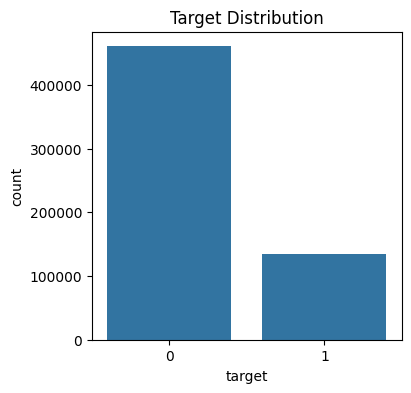

In [13]:
plt.figure(figsize=(4,4))
sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.show()


In [25]:
def plot_binned_target(df, feature, bins=50):
    temp = df[[feature, "target"]].copy()
    temp["bin"] = pd.qcut(temp[feature], q=bins, duplicates="drop")
    
    grouped = temp.groupby("bin")["target"].mean()
    
    plt.figure(figsize=(8,4))
    grouped.plot(marker="o")
    plt.ylabel("P(Heart Disease = Presence)")
    plt.title(f"{feature} vs Heart Disease (Binned)")
    plt.xticks(rotation=45)
    plt.show()


In [14]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

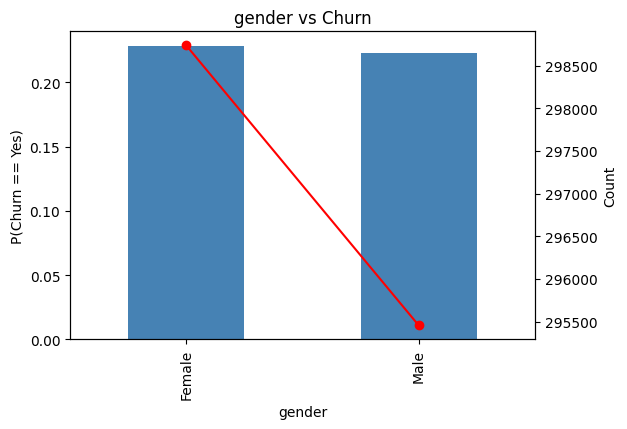

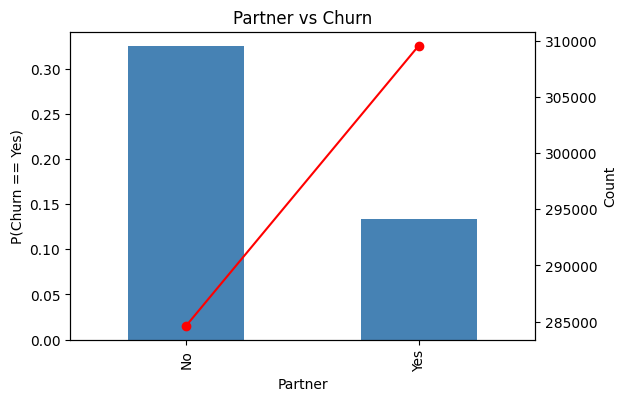

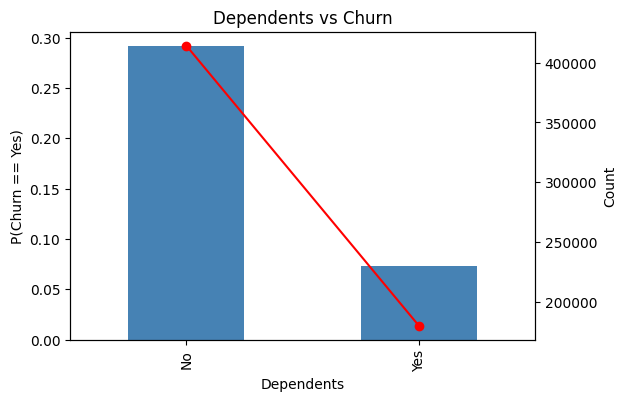

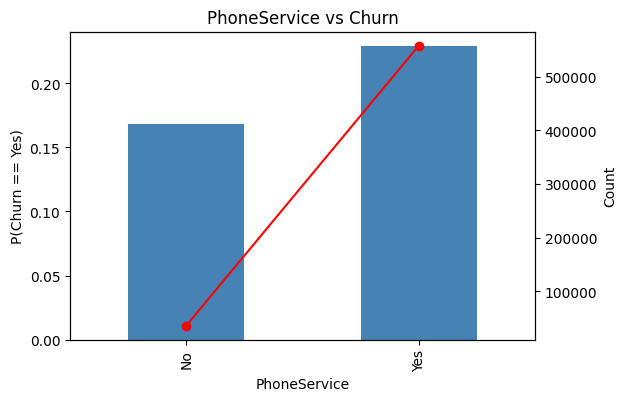

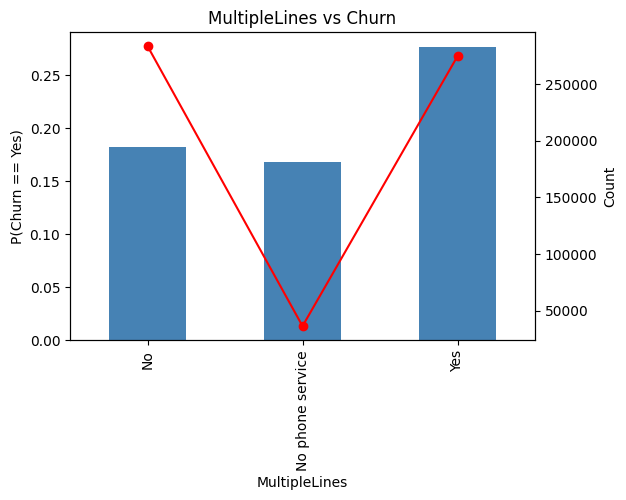

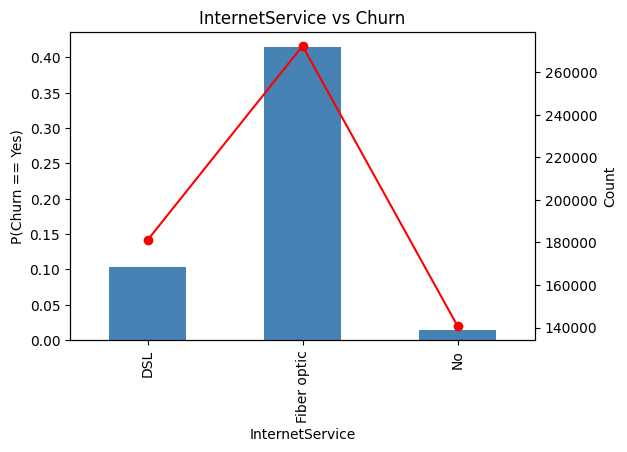

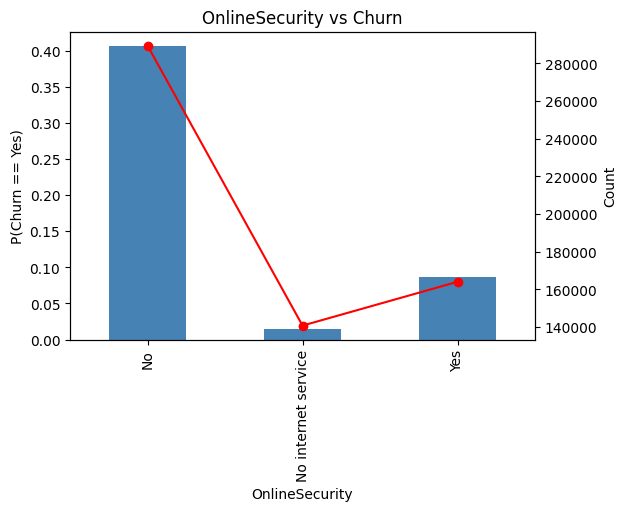

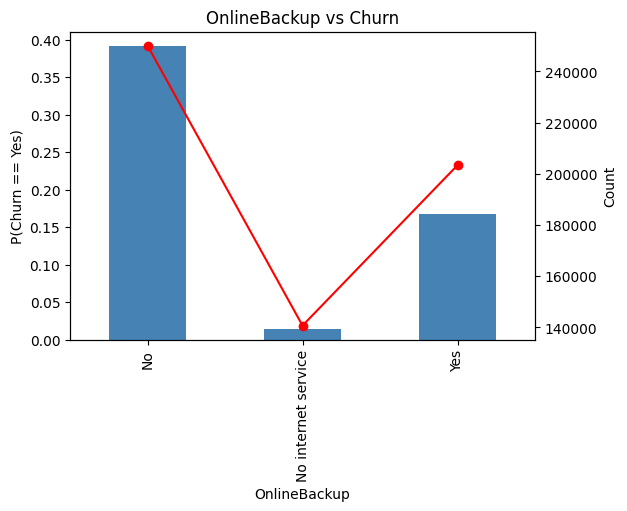

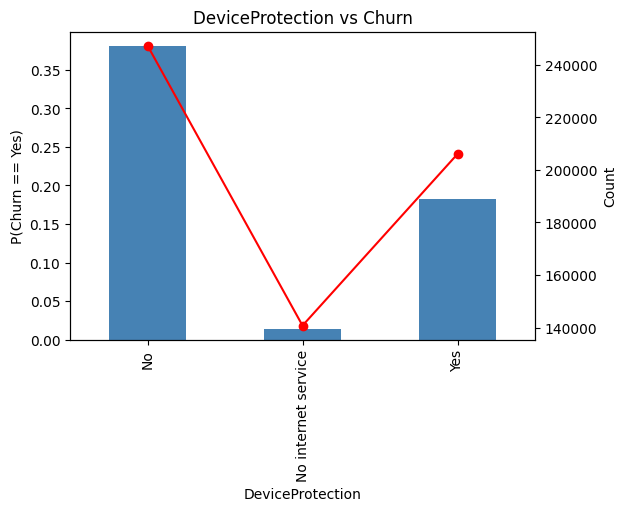

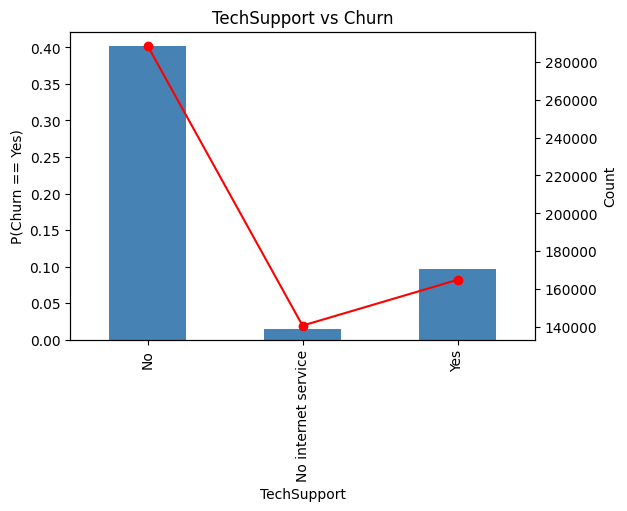

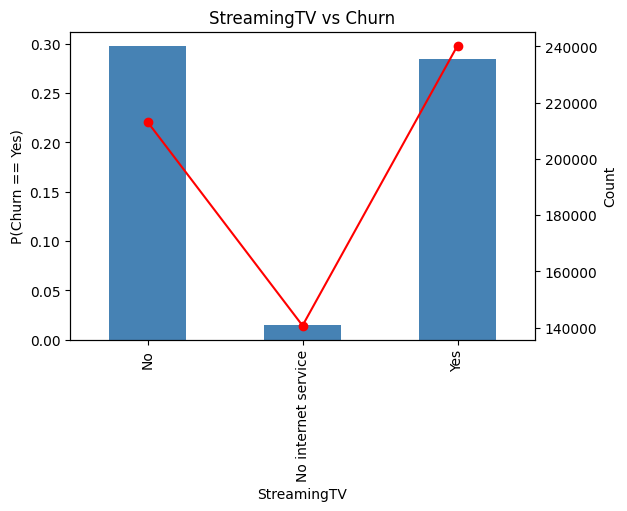

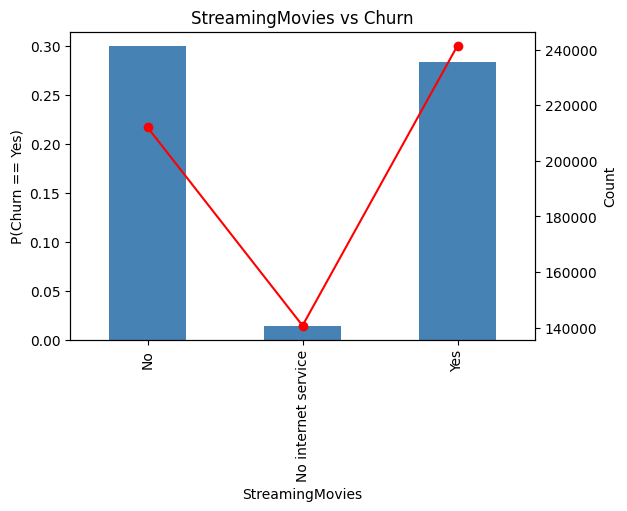

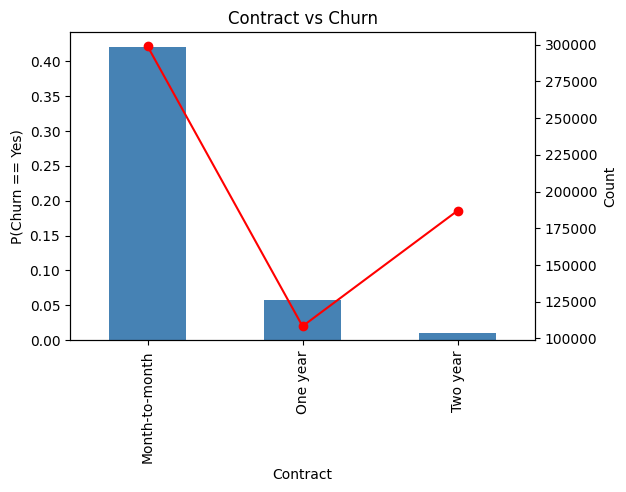

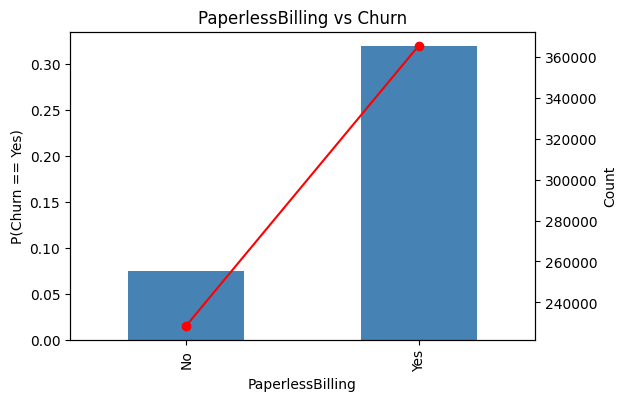

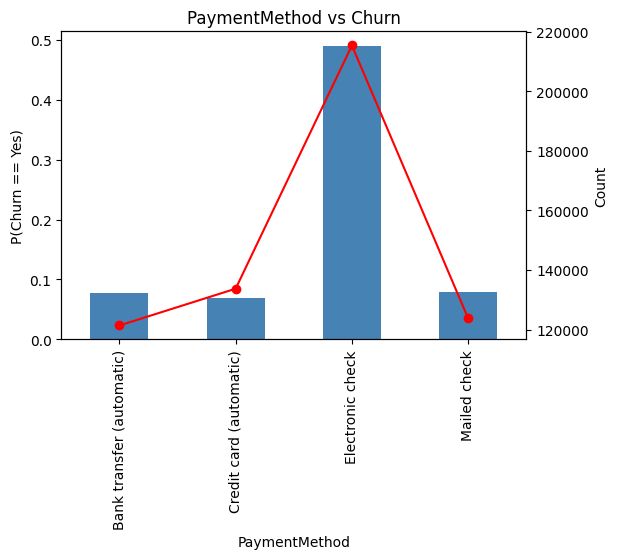

In [29]:
def plot_cat_target(df, feature):
    prob = df.groupby(feature)["target"].mean()
    count = df.groupby(feature)["target"].count()
    
    fig, ax1 = plt.subplots(figsize=(6,4))
    
    prob.plot(kind="bar", ax=ax1, color="steelblue")
    ax1.set_ylabel("P(Churn == Yes)")
    ax1.set_title(f"{feature} vs Churn")
    
    ax2 = ax1.twinx()
    count.plot(kind="line", ax=ax2, color="red", marker="o")
    ax2.set_ylabel("Count")
    
    plt.show()

for i in cat_cols:
    if i == 'Churn':
        continue
    plot_cat_target(df, i)


In [22]:
train.PaymentMethod.unique()

array(['Mailed check', 'Credit card (automatic)', 'Electronic check',
       'Bank transfer (automatic)'], dtype=object)

In [103]:
preprocess_data()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
0,1,0,1,1,29,1,1,2,2,1,2,2,1,1,1,1,1,60.10,1653.85,0
1,1,0,1,1,58,1,1,2,2,2,1,2,2,1,0,0,2,69.50,3778.20,0
2,1,0,1,1,58,1,2,1,1,2,1,1,2,2,2,1,3,100.40,5841.35,0
3,0,0,1,1,1,1,1,1,1,1,1,1,1,1,2,1,3,69.70,70.70,1
4,0,0,1,1,1,1,1,1,1,1,1,1,1,1,2,1,3,70.45,70.45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,1,0,1,1,57,1,2,1,1,1,2,1,2,2,0,0,0,97.55,5460.70,0
594190,0,0,1,1,72,1,2,2,2,2,2,2,2,2,0,0,0,91.95,6782.15,0
594191,0,0,1,1,72,1,2,3,0,0,0,0,0,0,0,0,2,24.40,1871.90,0
594192,0,0,1,1,32,1,2,1,1,1,1,1,1,2,2,1,3,86.00,2847.20,0


In [102]:

preprocess_data().corr()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
gender,1.000000,0.000103,NaN,NaN,0.001504,NaN,-0.014036,0.009630,-0.007987,-0.007438,-0.009024,-0.009006,-0.009538,-0.009142,0.000159,-0.005776,-0.001363,-0.013647,-0.006192,-0.006808
SeniorCitizen,0.000103,1.000000,NaN,NaN,-0.084291,NaN,0.140325,-0.273773,0.060054,0.118794,0.126154,0.057761,0.182345,0.181574,0.198653,0.199061,0.202752,0.229079,0.042786,0.236362
Partner,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,0.001504,-0.084291,NaN,NaN,1.000000,NaN,0.229202,0.141860,0.161531,0.168125,0.177976,0.177274,0.109560,0.110200,-0.753957,-0.113104,-0.306560,0.124043,0.769703,-0.418453
PhoneService,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,-0.014036,0.140325,NaN,NaN,0.229202,NaN,1.000000,-0.364621,0.152109,0.218903,0.239023,0.166762,0.291309,0.289145,-0.048217,0.216502,0.113917,0.533003,0.426951,0.109066
InternetService,0.009630,-0.273773,NaN,NaN,0.141860,NaN,-0.364621,1.000000,-0.579159,-0.659696,-0.674406,-0.588389,-0.755300,-0.754249,-0.433977,-0.534388,-0.422975,-0.902826,-0.370470,-0.408363
OnlineSecurity,-0.007987,0.060054,NaN,NaN,0.161531,NaN,0.152109,-0.579159,1.000000,0.747244,0.745017,0.783102,0.698795,0.699749,0.042933,0.290843,0.100511,0.667498,0.524226,0.039353
OnlineBackup,-0.007438,0.118794,NaN,NaN,0.168125,NaN,0.218903,-0.659696,0.747244,1.000000,0.757188,0.756234,0.742818,0.744088,0.089176,0.351762,0.161876,0.748134,0.570295,0.095632


In [ ]:
# Churn vs Gender
test_cats = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod',
]
for i in test_cats:
    sns.countplot(x=i, hue='Churn', data=train)
    plt.show()


In [105]:
train.describe(include=['object'])

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194,594194
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Female,Yes,No,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,No
freq,298738,309554,414362,557893,283384,272386,289474,250083,247377,288571,240301,241435,298918,365579,215372,460377


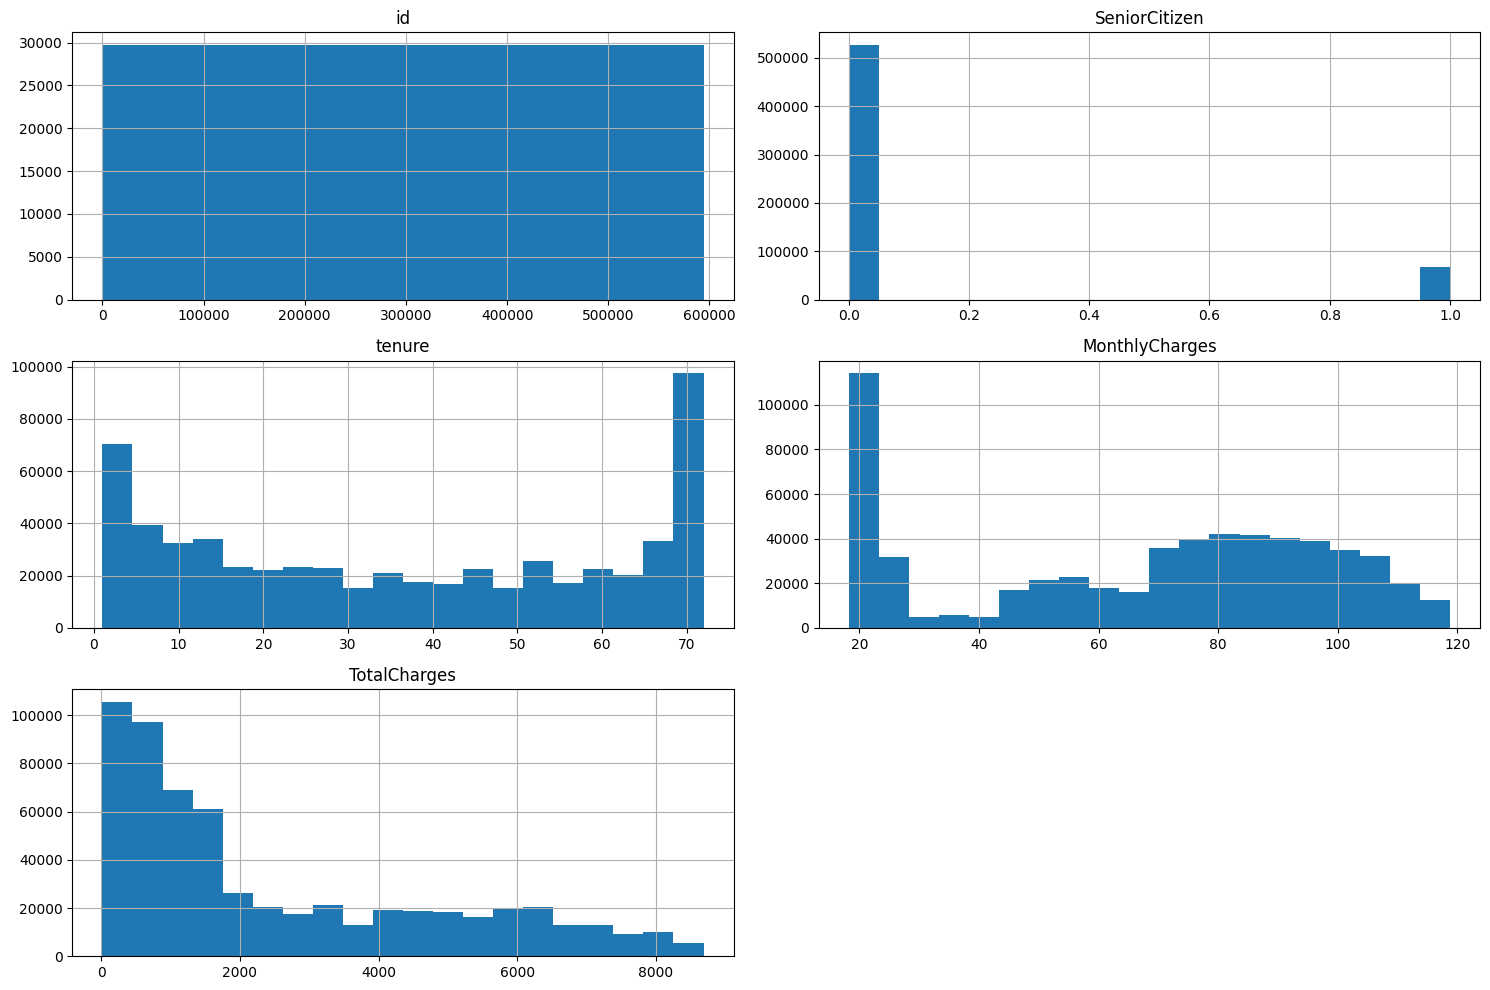

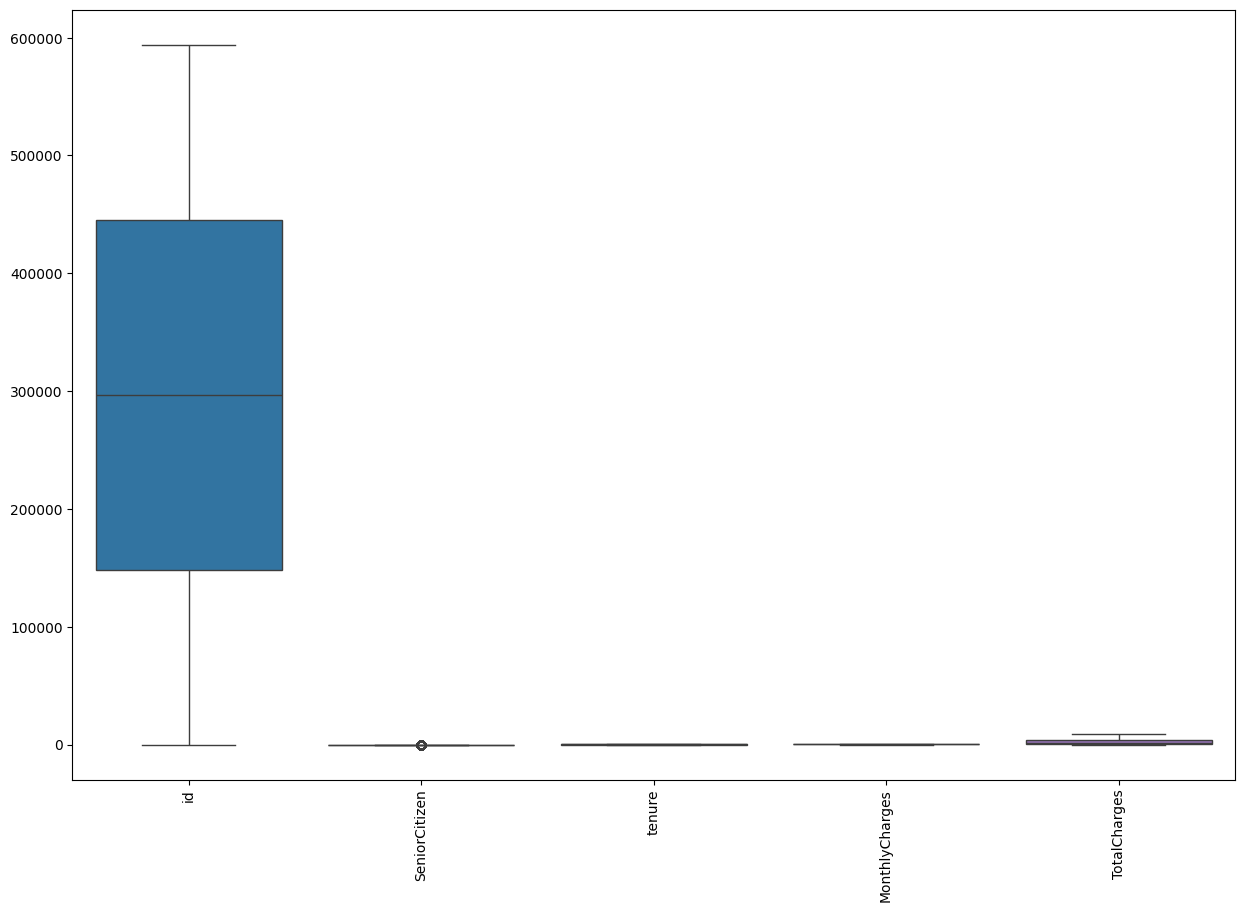

In [106]:
# Histograms for numerical columns
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns
train[numerical_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

# Boxplots for outliers (for individual numerical columns)
plt.figure(figsize=(15, 10))
sns.boxplot(data=train[numerical_cols])
plt.xticks(rotation=90)
plt.show()

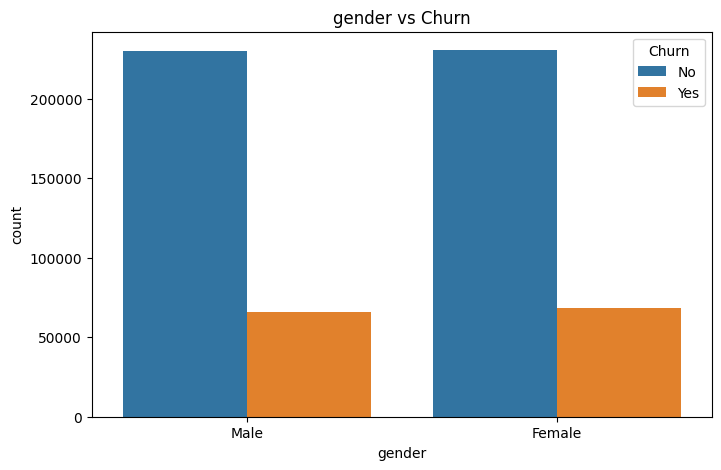

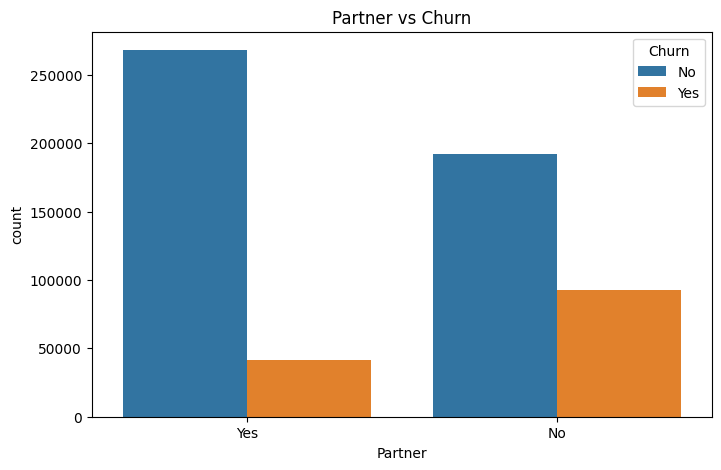

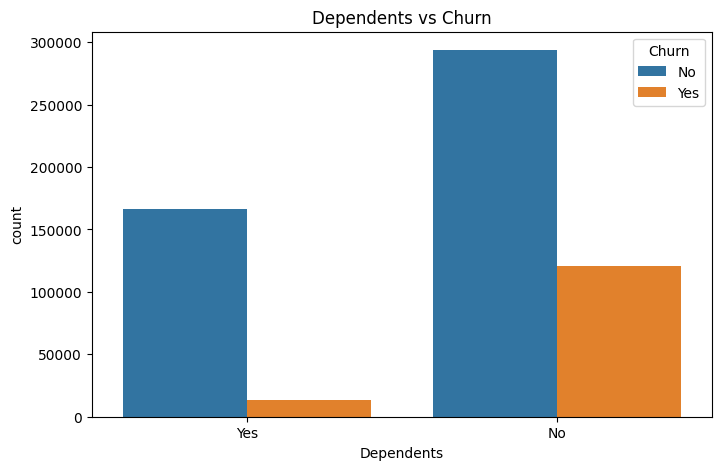

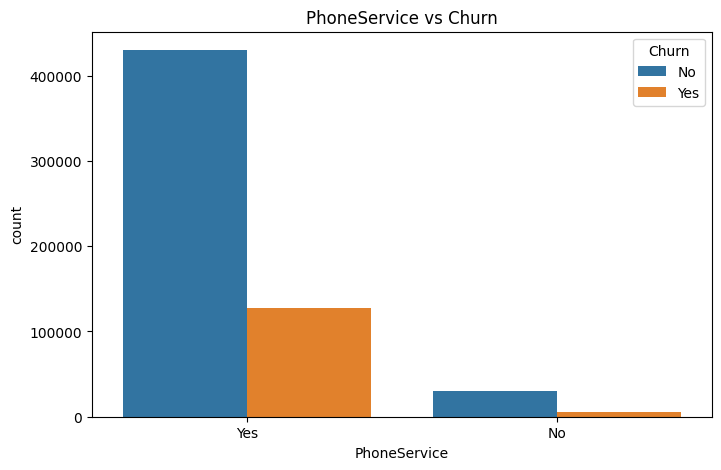

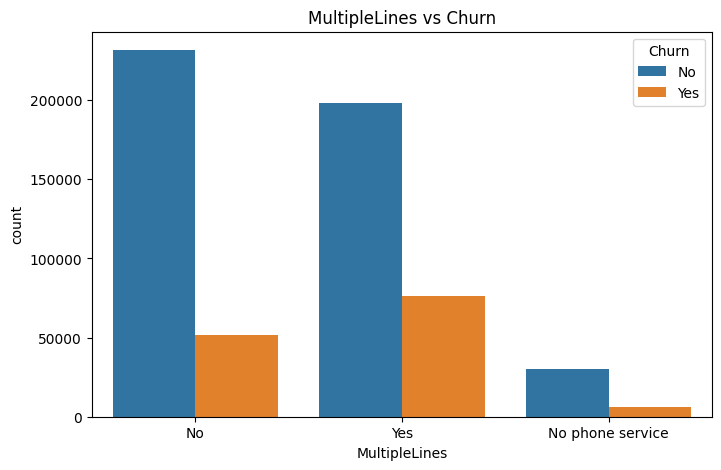

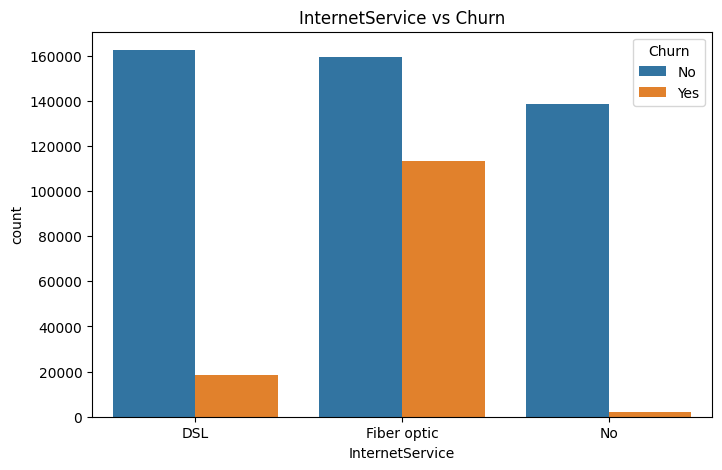

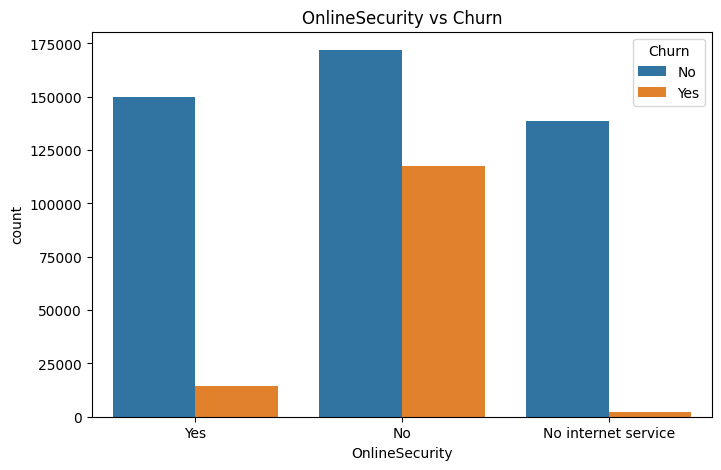

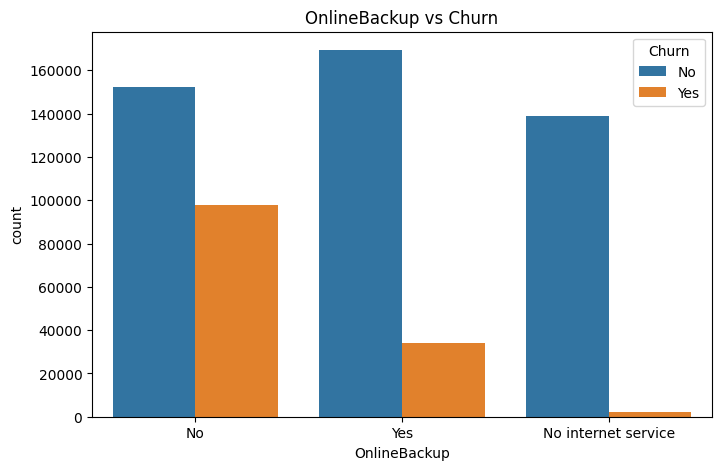

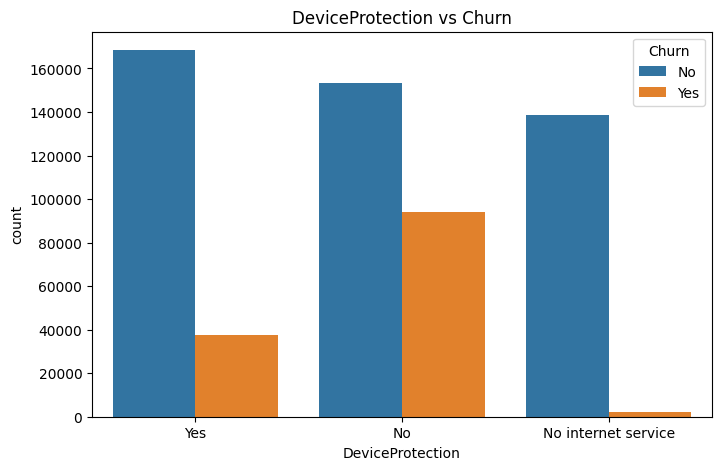

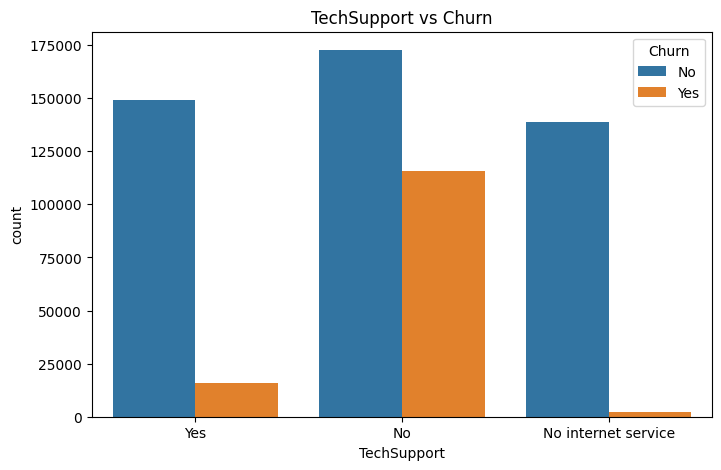

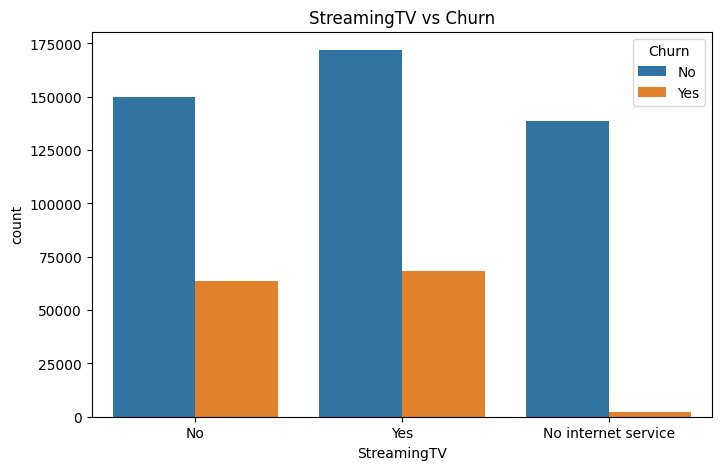

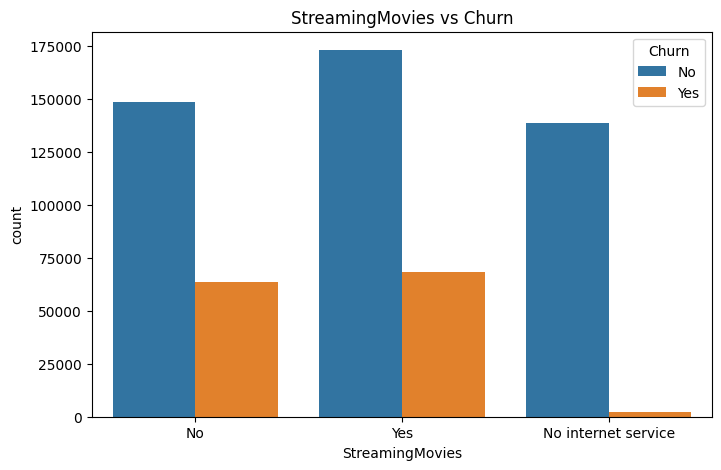

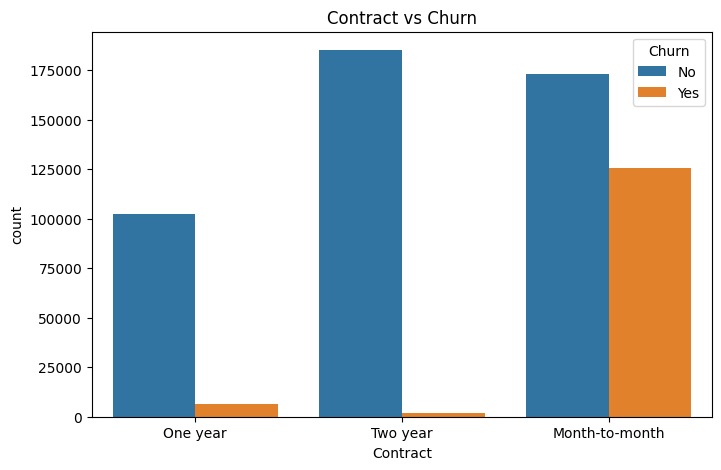

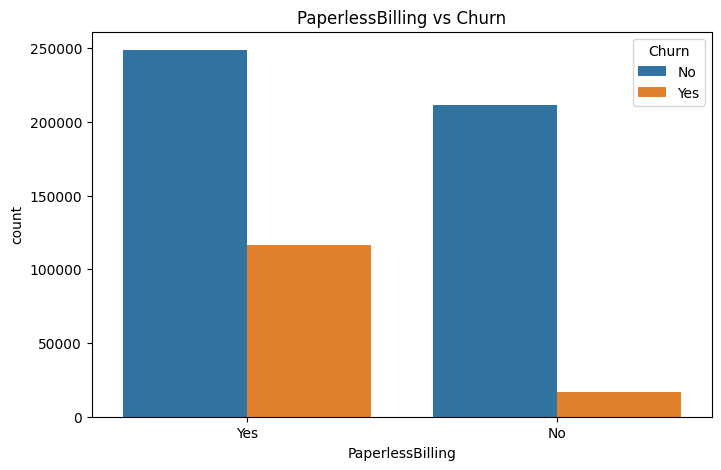

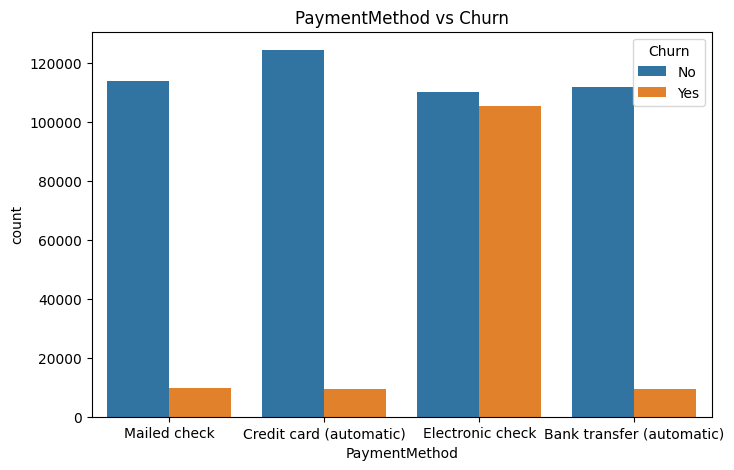

In [107]:
# Plot the distribution of categorical features
categorical_cols = train.select_dtypes(include=['object']).columns

# For each categorical variable, visualize its distribution
for col in categorical_cols:
    if col != 'Churn':  # Skip the target column
        plt.figure(figsize=(8, 5))
        sns.countplot(x=col, hue='Churn', data=train)
        plt.title(f'{col} vs Churn')
        plt.show()

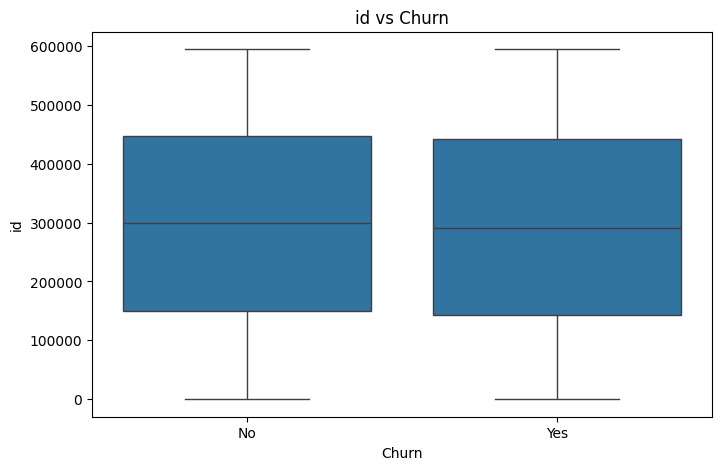

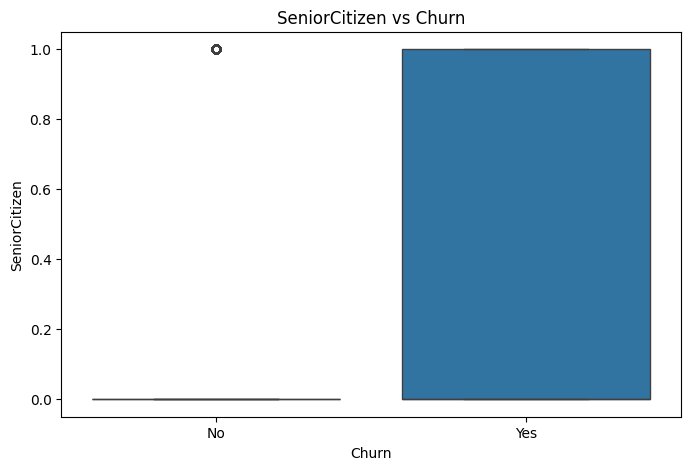

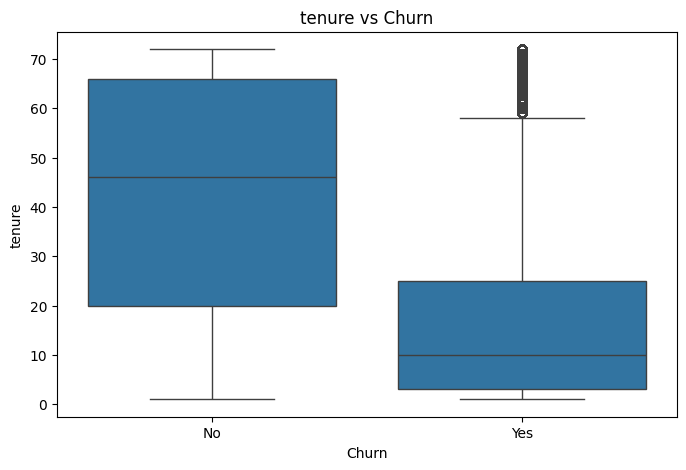

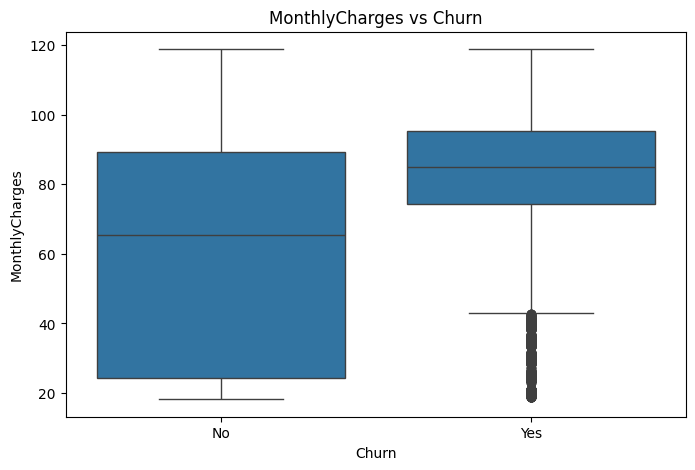

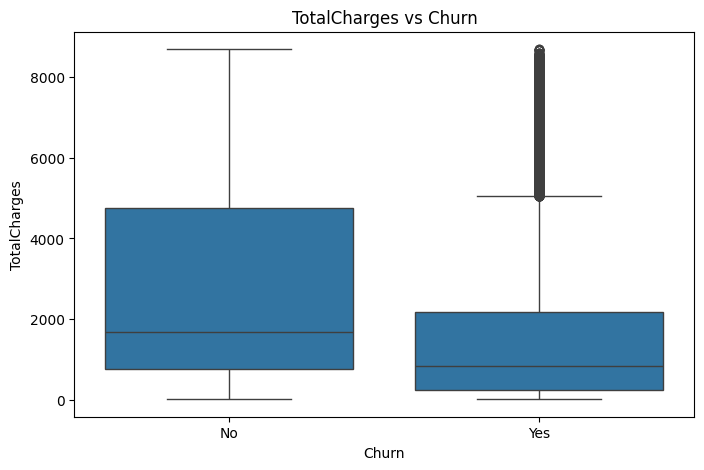

In [108]:
# Boxplots to visualize numerical features vs Churn
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Churn', y=col, data=train)
    plt.title(f'{col} vs Churn')
    plt.show()

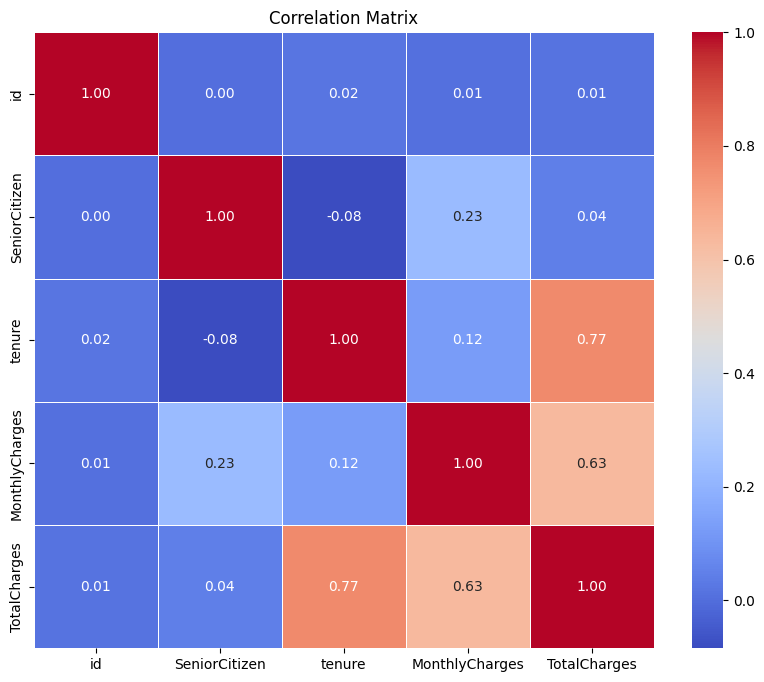

In [111]:
# Correlation matrix to understand relationships between numerical features
corr = train[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [112]:
from scipy.stats import chi2_contingency

# Chi-Square test for categorical columns
for col in categorical_cols:
    if col != 'Churn':
        contingency_table = pd.crosstab(train[col], train['Churn'])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        print(f'Chi-Square Test for {col}: p-value = {p}')

Chi-Square Test for gender: p-value = 1.561933705084728e-07
Chi-Square Test for Partner: p-value = 0.0
Chi-Square Test for Dependents: p-value = 0.0
Chi-Square Test for PhoneService: p-value = 8.013131829774979e-159
Chi-Square Test for MultipleLines: p-value = 0.0
Chi-Square Test for InternetService: p-value = 0.0
Chi-Square Test for OnlineSecurity: p-value = 0.0
Chi-Square Test for OnlineBackup: p-value = 0.0
Chi-Square Test for DeviceProtection: p-value = 0.0
Chi-Square Test for TechSupport: p-value = 0.0
Chi-Square Test for StreamingTV: p-value = 0.0
Chi-Square Test for StreamingMovies: p-value = 0.0
Chi-Square Test for Contract: p-value = 0.0
Chi-Square Test for PaperlessBilling: p-value = 0.0
Chi-Square Test for PaymentMethod: p-value = 0.0


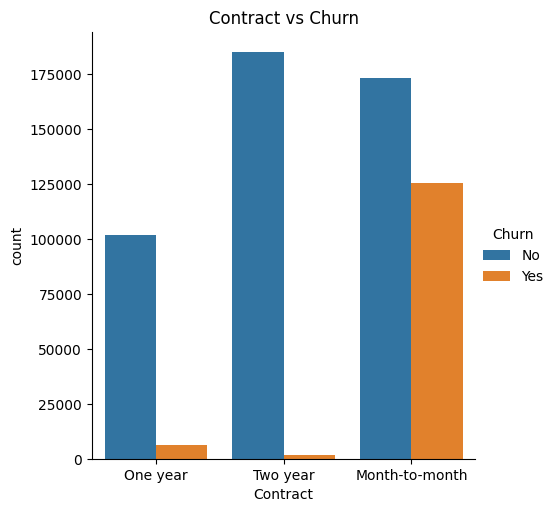

In [113]:
# Stacked barplot to see the relationship between two categorical variables
sns.catplot(x="Contract", hue="Churn", kind="count", data=train)
plt.title('Contract vs Churn')
plt.show()

In [101]:
df["OtherCharges"]=df.TotalCharges - df.MonthlyCharges
df[["OtherCharges", "MonthlyCharges", "TotalCharges", "target"]].corr()

,OtherCharges,MonthlyCharges,TotalCharges,target
OtherCharges,1.000000,0.626248,0.999947,-0.223830
MonthlyCharges,0.626248,1.000000,0.634237,0.272997
TotalCharges,0.999947,0.634237,1.000000,-0.218365
target,-0.223830,0.272997,-0.218365,1.000000


In [19]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,0
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,0
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,0
594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,0


In [119]:
def preprocess_data(df: pd.DataFrame = None):
    if df is None:
        df = train.copy()
        df['target'] = (df['Churn'] == 'Yes').astype(int)
        df = df.drop(columns='Churn')
    df = df.drop(columns=['id'])

    bins = [0, 6, 12, 24, 48, 64, 75]
    labels = [3, 6, 9, 12, 16, 24]
    df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, right=False)

    partner_map = {'Yes': 1, 'No': 1}
    df["Partner"] = df["Partner"].map(partner_map)

    dependents_map = {'Yes': 1, 'No': 1}
    df["Dependents"] = df["Dependents"].map(dependents_map)

    phoneservice_map = {'Yes': 1, 'No': 1}
    df["PhoneService"] = df["PhoneService"].map(phoneservice_map)

    internet_map = {'Fiber optic': 1, 'DSL': 2, 'No':3}
    df["InternetService"] = df["InternetService"].map(internet_map)    
    
    multiple_lines = {'Yes': 2, 'No': 1, 'No phone service': 0}
    df["MultipleLines"] = df["MultipleLines"].map(multiple_lines)

    online_security = {'Yes': 2, 'No': 1, 'No internet service': 0}
    df["OnlineSecurity"] = df["OnlineSecurity"].map(online_security)    
    
    device_protection = {'Yes': 2, 'No': 1, 'No internet service': 0}
    df["DeviceProtection"] = df["DeviceProtection"].map(device_protection)    
    
    TechSupport = {'Yes': 2, 'No': 1, 'No internet service': 0}
    df["TechSupport"] = df["TechSupport"].map(TechSupport)

    StreamingTV = {'Yes': 2, 'No': 1, 'No internet service': 0}
    df["StreamingTV"] = df["StreamingTV"].map(StreamingTV)

    PaperlessBilling = {'Yes': 1, 'No': 0}
    df["PaperlessBilling"] = df["PaperlessBilling"].map(PaperlessBilling)
    
    Contract = {'Month-to-month': 2, 'One year': 1, 'Two year': 0}
    df["Contract"] = df["Contract"].map(Contract)

    StreamingMovies = {'Yes': 2, 'No': 1, 'No internet service': 0}
    df["StreamingMovies"] = df["StreamingMovies"].map(StreamingMovies)

    PaymentMethod = {'Electronic check': 3, 'Credit card (automatic)': 2, "Mailed check": 1, "Bank transfer (automatic)": 0}
    df["PaymentMethod"] = df["PaymentMethod"].map(PaymentMethod)

    OnlineBackup = {'Yes': 2, 'No': 1, "No internet service": 0}
    df["OnlineBackup"] = df["OnlineBackup"].map(OnlineBackup)

    gender = {'Male': 1, 'Female': 0}
    df["gender"] = df["gender"].map(gender)

    return df

preprocess_data()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,target,tenure_group
0,1,0,1,1,29,1,1,2,2,1,...,2,1,1,1,1,1,60.10,1653.85,0,12
1,1,0,1,1,58,1,1,2,2,2,...,2,2,1,0,0,2,69.50,3778.20,0,16
2,1,0,1,1,58,1,2,1,1,2,...,1,2,2,2,1,3,100.40,5841.35,0,16
3,0,0,1,1,1,1,1,1,1,1,...,1,1,1,2,1,3,69.70,70.70,1,3
4,0,0,1,1,1,1,1,1,1,1,...,1,1,1,2,1,3,70.45,70.45,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,1,0,1,1,57,1,2,1,1,1,...,1,2,2,0,0,0,97.55,5460.70,0,16
594190,0,0,1,1,72,1,2,2,2,2,...,2,2,2,0,0,0,91.95,6782.15,0,24
594191,0,0,1,1,72,1,2,3,0,0,...,0,0,0,0,0,2,24.40,1871.90,0,24
594192,0,0,1,1,32,1,2,1,1,1,...,1,1,2,2,1,3,86.00,2847.20,0,12


In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import numpy as np

# ----------------------------
# Feature / target
# ----------------------------
train_raw = preprocess_data()

X = train_raw.drop(columns=["target"])
y = train_raw["target"]

# num_cols.extend(newly_adds)

# ----------------------------
# 5-fold Stratified CV
# ----------------------------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = {
    "accuracy": [],
    "roc_auc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

coefs = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------
    # Scaling (fit ONLY on train)
    # ----------------------------
    scaler = StandardScaler()

    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()

    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # ----------------------------
    # Model
    # ----------------------------
    log_reg = LogisticRegression(
        max_iter=10000,
        solver="lbfgs"
    )

    log_reg.fit(X_train_scaled, y_train)

    # ----------------------------
    # Evaluation
    # ----------------------------
    y_pred = log_reg.predict(X_val_scaled)
    y_proba = log_reg.predict_proba(X_val_scaled)[:, 1]

    metrics["accuracy"].append(accuracy_score(y_val, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_val, y_proba))
    metrics["precision"].append(precision_score(y_val, y_pred))
    metrics["recall"].append(recall_score(y_val, y_pred))
    metrics["f1"].append(f1_score(y_val, y_pred))

    coefs.append(log_reg.coef_[0])

    print(f"Fold {fold} done")

# ----------------------------
# Aggregate results
# ----------------------------
print("\nCV Results (mean ± std):")
for m, vals in metrics.items():
    print(f"{m.upper():10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# ----------------------------
# Average coefficients
# ----------------------------
coef_mean = pd.Series(
    np.mean(coefs, axis=0),
    index=X.columns
).sort_values(ascending=False)

print("\nAverage coefficients across folds:")
print(coef_mean)

print("\nAverage odds ratios:")
print(np.exp(coef_mean))


Fold 1 done
Fold 2 done
Fold 3 done
Fold 4 done
Fold 5 done

CV Results (mean ± std):
ACCURACY  : 0.8530 ± 0.0010
ROC_AUC   : 0.9064 ± 0.0010
PRECISION : 0.6820 ± 0.0029
RECALL    : 0.6507 ± 0.0034
F1        : 0.6659 ± 0.0021

Average coefficients across folds:
TotalCharges        0.820712
Contract            0.680154
StreamingTV         0.454513
StreamingMovies     0.432515
PaymentMethod       0.325329
PaperlessBilling    0.214971
MultipleLines       0.209631
SeniorCitizen       0.159878
DeviceProtection    0.011659
Dependents          0.000000
Partner             0.000000
PhoneService        0.000000
gender             -0.008531
OnlineBackup       -0.016831
TechSupport        -0.133182
OnlineSecurity     -0.243096
MonthlyCharges     -0.693755
InternetService    -1.146952
tenure             -1.816397
dtype: float64

Average odds ratios:
TotalCharges        2.272118
Contract            1.974182
StreamingTV         1.575406
StreamingMovies     1.541128
PaymentMethod       1.384487
Paper

Number of vessels fluro
0    445862
1    106978
2     54303
3     22857
Name: count, dtype: int64

## LGBM


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     92076
           1       0.71      0.64      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839

Fold 1 done with ROC-AUC: 0.9155985961079863
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     92076
           1       0.71      0.65      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    11883

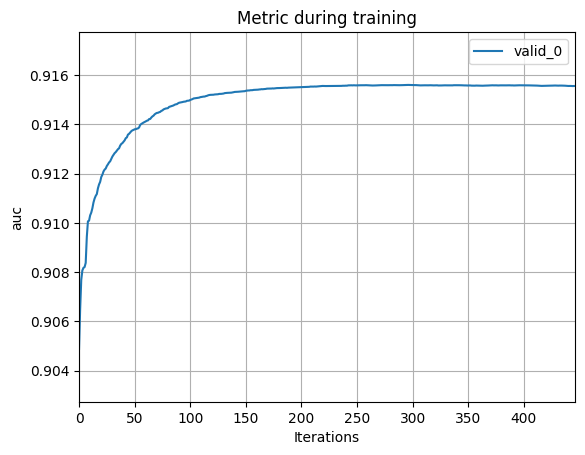

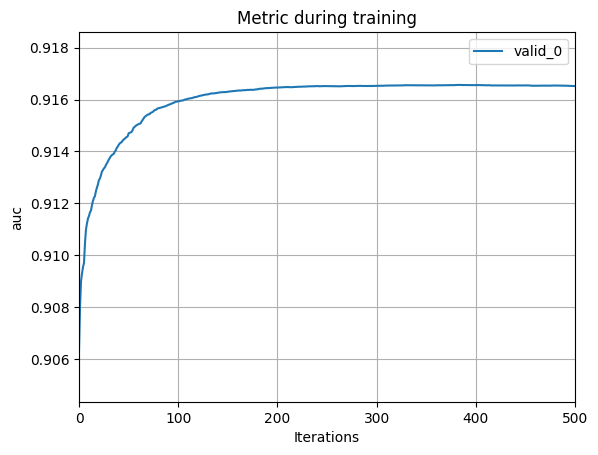

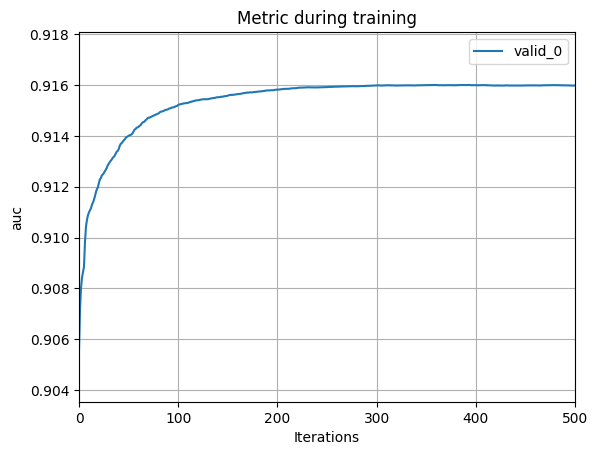

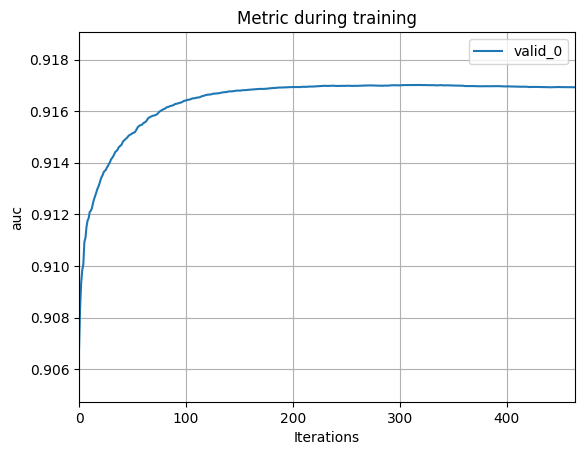

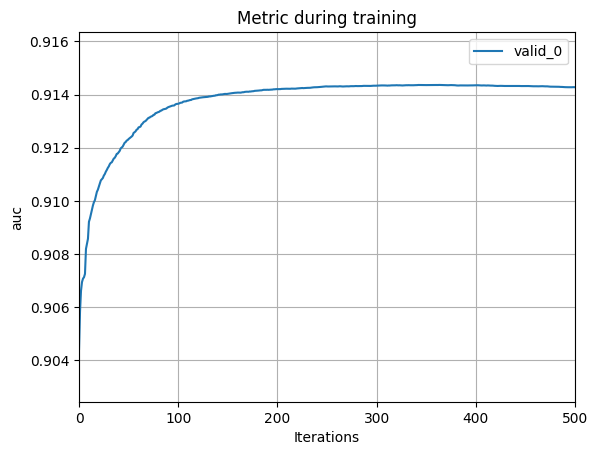

In [55]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import lightgbm as lgb
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd

# ----------------------------
# Feature / target
# ----------------------------
# X = df.drop(columns=["target"])
# y = df["target"]

# X_test = test.drop(columns='id')

train_raw = preprocess_data()
X = train_raw.drop(columns=["target"])
y = train_raw["target"]
test_raw = preprocess_data(test)

X_test = test_raw
num_cols = X.columns

# num_cols = [
#     'Thallium', 'Sex', 'Slope of ST', 'Age',
#     'Number of vessels fluro', 'Exercise angina',
#     'Max HR', 'Chest pain type', 'EKG results',
#     'Cholesterol', 'FBS over 120', 'BP',
#     'ST depression'
# ]
# cat_cols = [
#     # 'Sex',
#     'Chest pain type',
#     # 'Exercise angina',
#     # 'Number of vessels fluro',
#     # 'Thallium'
# ]
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    '''Preprocess of features.'''
    # df['Number of vessels fluro'] = (df['Number of vessels fluro'] - 3) * -1
    new_cols = []
    # bins = [0, 35, 55, 70, 80]
    # labels = [1, 2, 3, 4]
    # df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

    # X['Thallium_x2'] = X['Thallium'] / X['Slope of ST']
    # X_test['Thallium_x2'] = X_test['Thallium'] / X_test['Slope of ST']
    
    # bins = [0, 1, 2, 3, 4.5, 5.5]
    # labels = [1, 2, 3, 4, 5]
    # df['dep x age'] = pd.cut(df['ST depression'], bins=bins, labels=labels, right=False).astype('float')
    # df['dep x age'] = df['Age'] / df['dep x age']
    # new_cols.append('dep x age')
    # df[cat_cols] = df[cat_cols].astype('category')
    # data = pd.get_dummies(df[cat_cols], drop_first=True)
    # print(data.columns)
    # df = pd.concat([df.drop(columns=cat_cols), data], axis=1)
    # print(df.columns)
    # new_cols = ['Age Group']
    # df['Thallium_x_age'] = df['Thallium'] * (df['Age']**0.5)
    # df["num_fluro"] = (df['Number of vessels fluro'] > 0).astype(int)
    # df['st_slope'] = (df['Slope of ST'] > 1).astype(int)
    # df = df.drop(columns= [ 'Slope of ST'])
    # df["st_x_age"] = (df['Age'] * np.log1p(df['ST depression']))
    # new_cols.append('st_x_age')
    # for i in new_cols:
    #     if i not in num_cols:
    #         num_cols.append(i)
    # num_cols.append('Thallium_x2')
    return df


X = preprocess(X[num_cols].copy())
X_test = preprocess(X_test[num_cols].copy())

print(X.columns)

# ----------------------------
# 5-fold Stratified CV
# ----------------------------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = {
    "accuracy": [],
    "roc_auc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

importances = []

X_res = np.zeros(len(X_test))
X_res_oof = np.zeros(len(X))


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------
    # Model
    # ----------------------------
    xgb = LGBMClassifier(
        objective="binary",
        metric="auc",

        n_estimators=500,
        learning_rate=0.1,

        max_depth=-1,          # let num_leaves control complexity
        num_leaves=48,

        subsample=0.9,
        colsample_bytree=0.9,

        min_child_samples=100,
        reg_alpha=5,
        reg_lambda=5,

        random_state=42,
        n_jobs=-1,
        verbose=-1,
        early_stopping_rounds = 150
    )


    xgb.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        # verbose=False
    )

    # ----------------------------
    # Evaluation
    # ----------------------------
    y_pred = xgb.predict(X_val, num_iteration=xgb.best_iteration_)
    y_proba = xgb.predict_proba(X_val, num_iteration=xgb.best_iteration_)[:, 1]
    X_res += xgb.predict_proba(X_test, num_iteration=xgb.best_iteration_)[:, 1]/5
    X_res_oof += xgb.predict_proba(X, num_iteration=xgb.best_iteration_)[:, 1]/5

    metrics["accuracy"].append(accuracy_score(y_val, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_val, y_proba))
    metrics["precision"].append(precision_score(y_val, y_pred))
    metrics["recall"].append(recall_score(y_val, y_pred))
    metrics["f1"].append(f1_score(y_val, y_pred))

    importances.append(xgb.feature_importances_)
    lgb.plot_metric(booster=xgb)
    print(classification_report(y_val, y_pred))
    print(f"Fold {fold} done", f"with ROC-AUC: {metrics['roc_auc'][-1]}")

# ----------------------------
# Aggregate results
# ----------------------------
print("\nCV Results (mean ± std):")
for m, vals in metrics.items():
    print(f"{m.upper():10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# ----------------------------
# Average feature importance
# ----------------------------
importance_mean = pd.Series(
    np.mean(importances, axis=0),
    index=X.columns
).sort_values(ascending=False)

print("\nAverage feature importances:")
print(importance_mean)

sub_df = pd.DataFrame({'id': test['id'], 'Churn': X_res})


In [53]:
os.listdir()

['data', 'eda.ipynb']

In [62]:
os.listdir('results')

['sub01.csv', 'sub02.csv']

In [91]:
def write_results():
    files = os.listdir('results')
    counts = []
    for i in files:
        name = i.split('.')[0]
        no = name.split('b')[-1]
        no = int(no) 
        counts.append(no)
    max_no = max(counts) + 1
    print(f"Saving File no{max_no:02d}")
    sub_df = pd.DataFrame({'id': test['id'], 'Churn': X_res})
    sub_df.to_csv(f"results/sub{max_no:2d}.csv", index=False)

In [89]:
write_results()

04


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,1,0,1,1,29,1,1,2,2,1,2,2,1,1,1,1,1,60.10,1653.85
1,1,0,1,1,58,1,1,2,2,2,1,2,2,1,0,0,2,69.50,3778.20
2,1,0,1,1,58,1,2,1,1,2,1,1,2,2,2,1,3,100.40,5841.35
4,0,0,1,1,1,1,1,1,1,1,1,1,1,1,2,1,3,70.45,70.45
8,0,1,1,1,1,1,2,1,1,1,2,1,1,1,2,1,3,79.55,79.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,1,0,1,1,57,1,2,1,1,1,2,1,2,2,0,0,0,97.55,5460.70
594190,0,0,1,1,72,1,2,2,2,2,2,2,2,2,0,0,0,91.95,6782.15
594191,0,0,1,1,72,1,2,3,0,0,0,0,0,0,0,0,2,24.40,1871.90
594192,0,0,1,1,32,1,2,1,1,1,1,1,1,2,2,1,3,86.00,2847.20


In [93]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'tenure_group'],
      dtype='object')
              precision    recall  f1-score   support

           0       0.96      0.80      0.87     92076
           1       0.56      0.87      0.69     26763

    accuracy                           0.82    118839
   macro avg       0.76      0.84      0.78    118839
weighted avg       0.87      0.82      0.83    118839

Fold 1 done with ROC-AUC: 0.9154200338381727
              precision    recall  f1-score   support

           0       0.96      0.80      0.87     92076
           1       0.56      0.88      0.68     26763

    accuracy                           0.82    118839
   macro avg       0.76      0.84   

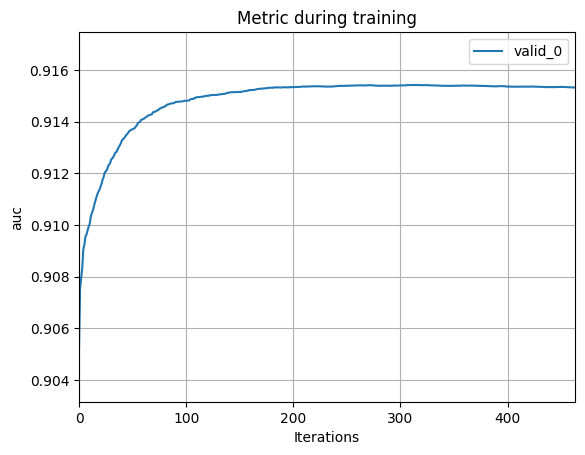

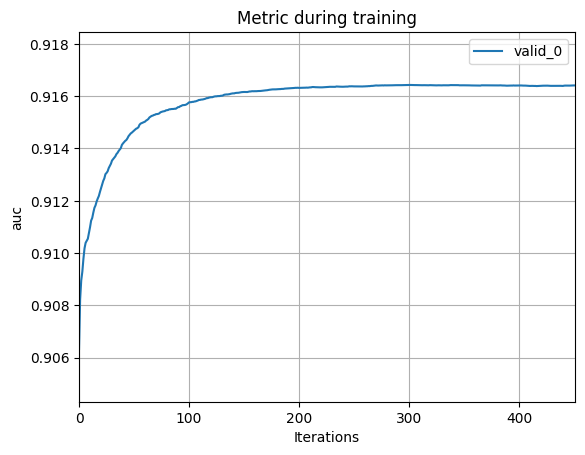

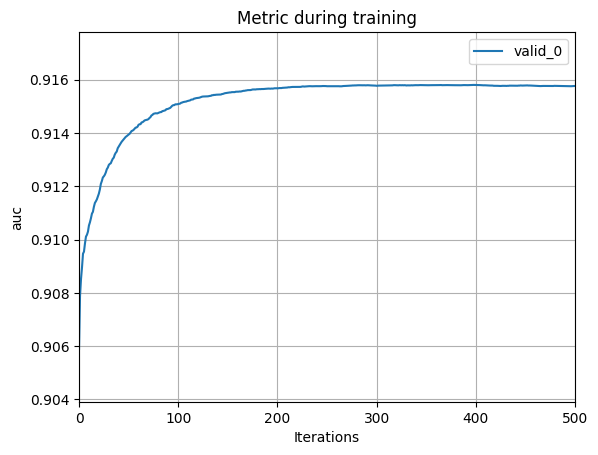

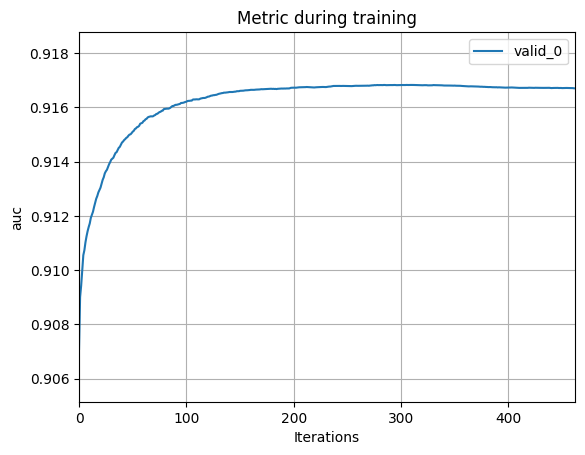

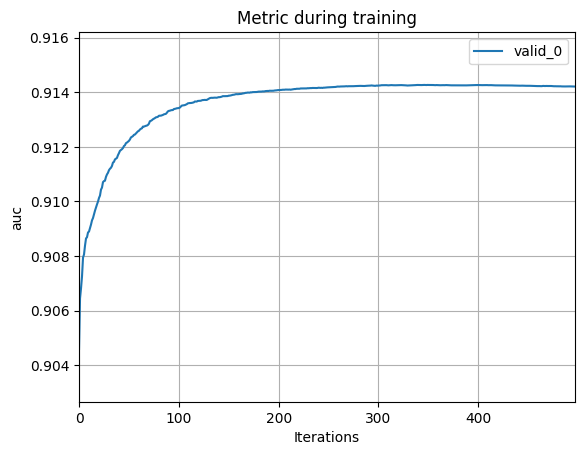

In [120]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
import lightgbm as lgb
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np
import pandas as pd


train_raw = preprocess_data()
X = train_raw.drop(columns=["target"])
y = train_raw["target"]
test_raw = preprocess_data(test)

X_test = test_raw
num_cols = X.columns

category_cols = [
    # 'gender',
    # 'Partner',
    # 'Dependents',
    # 'PhoneService',
    # 'MultipleLines',
    # 'InternetService',
    # 'OnlineSecurity',
    # 'OnlineBackup',
    # 'DeviceProtection',
    # 'TechSupport',
    # 'StreamingTV',
    # 'StreamingMovies',
    # 'Contract',
    # 'PaperlessBilling',
    # 'PaymentMethod',
]

def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    '''Preprocess of features.'''
    # df['Number of vessels fluro'] = (df['Number of vessels fluro'] - 3) * -1
    for i in category_cols:
        df[i] = df[i].astype('category')
    new_cols = []
    return df


X = preprocess(X[num_cols].copy())
X_test = preprocess(X_test[num_cols].copy())

print(X.columns)

# ----------------------------
# 5-fold Stratified CV
# ----------------------------
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

metrics = {
    "accuracy": [],
    "roc_auc": [],
    "precision": [],
    "recall": [],
    "f1": []
}

importances = []

X_res = np.zeros(len(X_test))
X_res_oof = np.zeros(len(X))


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # ----------------------------
    # Model
    # ----------------------------
    lgb_model = LGBMClassifier(
        objective="binary",
        metric="auc",

        n_estimators=500,
        learning_rate=0.1,

        max_depth=-1,          # let num_leaves control complexity
        num_leaves=48,

        subsample=0.9,
        colsample_bytree=0.9,

        min_child_samples=100,
        reg_alpha=5,
        reg_lambda=5,

        is_unbalance =True,

        random_state=42,
        n_jobs=-1,
        verbose=-1,
        early_stopping_rounds = 150
    )


    lgb_model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        categorical_feature = category_cols,
        # verbose=False
    )

    # ----------------------------
    # Evaluation
    # ----------------------------
    y_pred = lgb_model.predict(X_val, num_iteration=lgb_model.best_iteration_)
    y_proba = lgb_model.predict_proba(X_val, num_iteration=lgb_model.best_iteration_)[:, 1]
    X_res += lgb_model.predict_proba(X_test, num_iteration=lgb_model.best_iteration_)[:, 1]/5
    X_res_oof += lgb_model.predict_proba(X, num_iteration=lgb_model.best_iteration_)[:, 1]/5

    metrics["accuracy"].append(accuracy_score(y_val, y_pred))
    metrics["roc_auc"].append(roc_auc_score(y_val, y_proba))
    metrics["precision"].append(precision_score(y_val, y_pred))
    metrics["recall"].append(recall_score(y_val, y_pred))
    metrics["f1"].append(f1_score(y_val, y_pred))

    importances.append(lgb_model.feature_importances_)
    lgb.plot_metric(booster=lgb_model)
    print(classification_report(y_val, y_pred))
    print(f"Fold {fold} done", f"with ROC-AUC: {metrics['roc_auc'][-1]}")

# ----------------------------
# Aggregate results
# ----------------------------
print("\nCV Results (mean ± std):")
for m, vals in metrics.items():
    print(f"{m.upper():10s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

# ----------------------------
# Average feature importance
# ----------------------------
importance_mean = pd.Series(
    np.mean(importances, axis=0),
    index=X.columns
).sort_values(ascending=False)

print("\nAverage feature importances:")
print(importance_mean)

sub_df = pd.DataFrame({'id': test['id'], 'Churn': X_res})


In [1]:
train_data_path = r"D:\Dsoft\Projects\ML\data\customer_churn\data\train.parquet"

In [7]:
import os
os.listdir("../")

['.gitkeep',
 'breast_cancer.csv',
 'cibilscore',
 'cibilscore.csv',
 'customer_churn',
 'diabetes_prediction',
 'heart_disease',
 'islp',
 'loan_payback',
 'Rainfall.csv',
 'road_accidents',
 'student_test_scores']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import warnings
warnings.filterwarnings('ignore')


class ComprehensiveEDA:
    """
    A comprehensive EDA class with modular analysis components.
    You can run individual analyses, a subset, or all of them.
    
    Available analyses (method names):
        missing_analysis
        target_analysis
        univariate_analysis
        bivariate_analysis
        target_vs_features
        correlation_with_target
        grouped_analysis
        outlier_analysis
        duplicate_analysis
        vif_analysis
        mutual_information_analysis
        statistical_validation
        leakage_detection
        feature_interactions
        missing_as_signal
        drift_detection
        encoding_decisions
        categorical_interactions
        feature_combination_predictiveness
    """
    
    AVAILABLE_ANALYSES = [
        'missing_analysis',
        'target_analysis',
        'univariate_analysis',
        'bivariate_analysis',
        'target_vs_features',
        'correlation_with_target',
        'grouped_analysis',
        'outlier_analysis',
        'duplicate_analysis',
        'vif_analysis',
        'mutual_information_analysis',
        'statistical_validation',
        'leakage_detection',
        'feature_interactions',
        'missing_as_signal',
        'drift_detection',
        'encoding_decisions',
        'categorical_interactions',
        'feature_combination_predictiveness'
    ]

    def __init__(self, file_path, target, task_no, 
                categorical_variance_threshold=0.01,
                categorical_cardinality_threshold=None,
                show_guidance=False):
        """
        Parameters:
        -----------
        file_path : str
            Path to the dataset (CSV, Excel, or Parquet).
        target : str
            Name of the target column.
        task_no : str
            One of 'regression': 1, 'binary classification': 2, or 'multi classification': 3.
        categorical_variance_threshold : float, default=0.01
            Numeric columns with variance below this threshold are treated as categorical.
        categorical_cardinality_threshold : int or None, default=None
            Numeric columns with unique values <= this threshold are treated as categorical.
            If None, the threshold is automatically computed as:
                clamp( int(0.05 * n_rows), min=10, max=50 )
            where n_rows is the number of rows in the dataset.
        show_guidance : bool, default=False
            If True, prints interpretation guidance after each analysis.
        """
        self.file_path = file_path
        self.target = target
        task_map = {
            1: 'regression',
            2: 'binary',
            3: 'multi'
        }
        self.task = task_map[int(task_no)]
        self.cat_var_threshold = categorical_variance_threshold
        self.show_guidance = show_guidance
        self.report = []

        # Load data and identify feature types
        self.df = self._load_data()
        self._validate_target()
        self._detect_datetime_columns()

        # Determine cardinality threshold (auto if None)
        n_rows = len(self.df)
        if categorical_cardinality_threshold is None:
            auto_thresh = int(0.05 * n_rows)
            self.cat_card_threshold = max(10, min(50, auto_thresh))
            logging.info(f"Auto-set categorical cardinality threshold to {self.cat_card_threshold} (5% of {n_rows} rows, clamped to [10,50])")
        else:
            self.cat_card_threshold = categorical_cardinality_threshold
            logging.info(f"Using user-provided categorical cardinality threshold: {self.cat_card_threshold}")

        self.num_cols, self.cat_cols, self.dt_cols = self._get_feature_types()

        # Setup logging (only if no handlers exist)
        if not logging.getLogger().handlers:
            logging.basicConfig(level=logging.INFO,
                                format='%(asctime)s - %(levelname)s - %(message)s',
                                handlers=[logging.StreamHandler(),
                                        logging.FileHandler('eda.log')])
        logging.info(f"EDA initialized: target={target}, task={self.task}, shape={self.df.shape}")

    # -------------------------------------------------------------------------
    # 1. Data loading
    # -------------------------------------------------------------------------
    def _load_data(self):
        """Load dataset from CSV/Excel/Parquet file."""
        try:
            if self.file_path.endswith('.csv'):
                return pd.read_csv(self.file_path)
            elif self.file_path.endswith(('.xlsx', '.xls')):
                return pd.read_excel(self.file_path)
            elif self.file_path.endswith('.parquet'):
                return pd.read_parquet(self.file_path)            
            else:
                raise ValueError("Unsupported file format. Use CSV/Excel/Parquet.")
        except Exception as e:
            logging.error(f"Failed to load dataset: {e}")
            raise

    # -------------------------------------------------------------------------
    # 2. Target validation
    # -------------------------------------------------------------------------
    def _validate_target(self):
        """Check that target exists and task is valid."""
        if self.target not in self.df.columns:
            raise ValueError(f"Target column '{self.target}' not found in dataset.")
        if self.task not in ['regression', 'binary', 'multi']:
            raise ValueError("Task must be 'regression', 'binary', or 'multi'.")

    # -------------------------------------------------------------------------
    # 2b. Detect datetime columns stored as objects
    # -------------------------------------------------------------------------
    def _detect_datetime_columns(self):
        """Convert object columns that look like dates to datetime."""
        for col in self.df.select_dtypes(include='object').columns:
            try:
                sample = self.df[col].dropna().iloc[0]
                pd.to_datetime(sample)
                self.df[col] = pd.to_datetime(self.df[col])
                logging.info(f"Column '{col}' converted to datetime.")
            except (ValueError, TypeError, IndexError):
                continue

    # -------------------------------------------------------------------------
    # 3. Feature type detection
    # -------------------------------------------------------------------------
    def _get_feature_types(self):
        """Identify numeric, categorical, and datetime columns.
        Move low-variance or low-cardinality numeric columns to categorical."""
        num = self.df.select_dtypes(include=np.number).columns.tolist()
        cat = self.df.select_dtypes(include='object').columns.tolist()
        dt = self.df.select_dtypes(include=['datetime', 'datetime64']).columns.tolist()

        if self.target in num:
            num.remove(self.target)
        if self.target in cat:
            cat.remove(self.target)
        if self.target in dt:
            dt.remove(self.target)

        for col in num[:]:
            if self.df[col].isnull().mean() > 0.5:
                continue
            n_unique = self.df[col].nunique()
            if n_unique <= self.cat_card_threshold:
                cat.append(col)
                num.remove(col)
                msg = f"Column '{col}' moved to categorical (unique values={n_unique} <= threshold {self.cat_card_threshold})"
                logging.info(msg)
                self.report.append(msg)
                continue
            var = self.df[col].var()
            if var < self.cat_var_threshold:
                cat.append(col)
                num.remove(col)
                msg = f"Column '{col}' moved to categorical (variance={var:.6f} < threshold {self.cat_var_threshold})"
                logging.info(msg)
                self.report.append(msg)

        return num, cat, dt

    # -------------------------------------------------------------------------
    # 4. Missing data analysis
    # -------------------------------------------------------------------------
    def missing_analysis(self):
        """Visualise missing values (heatmap + bar plot)."""
        missing = self.df.isnull().sum()
        missing = missing[missing > 0]

        if missing.empty:
            logging.info("No missing values found.")
            self.report.append("No missing values found.")
            if self.show_guidance:
                print("\n[Interpretation] No missing values – good data quality.")
            return

        logging.info(f"Missing values:\n{missing}")
        self.report.append(f"Missing values per column:\n{missing}")

        n_rows = len(self.df)
        if n_rows > 10000:
            sample_df = self.df.sample(n=10000, random_state=42)
            logging.info("Sampling 10,000 rows for heatmap due to large dataset.")
        else:
            sample_df = self.df
        plt.figure(figsize=(12, 6))
        sns.heatmap(sample_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
        plt.title("Missing Data Heatmap")
        plt.tight_layout()
        plt.show()

        missing_pct = (missing / len(self.df)) * 100
        plt.figure(figsize=(12, 6))
        missing_pct.sort_values().plot(kind='bar')
        plt.ylabel('Percentage Missing')
        plt.title('Missing Data Percentage by Column')
        plt.tight_layout()
        plt.show()

        if self.show_guidance:
            self._print_guidance('missing_analysis')

    # -------------------------------------------------------------------------
    # 5. Target variable analysis
    # -------------------------------------------------------------------------
    def target_analysis(self):
        """Analyse target distribution (histogram + boxplot for regression;
           bar + pie for classification)."""
        logging.info("===== TARGET ANALYSIS =====")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax1, ax2 = axes

        if self.task == 'regression':
            sns.histplot(self.df[self.target], kde=True, ax=ax1)
            ax1.set_title(f"Distribution of {self.target}")
            sns.boxplot(x=self.df[self.target], ax=ax2)
            ax2.set_title(f"Boxplot of {self.target}")
            stats = self.df[self.target].describe()
            logging.info(f"Target statistics:\n{stats}")
            self.report.append(f"Target statistics:\n{stats}")
        else:
            vc = self.df[self.target].value_counts()
            sns.barplot(x=vc.index, y=vc.values, ax=ax1)
            ax1.set_title(f"Class Distribution of {self.target}")
            ax1.set_xlabel('Class')
            ax1.set_ylabel('Count')
            for i, val in enumerate(vc.values):
                ax1.text(i, val + 0.5, str(val), ha='center')
            ax2.pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90)
            ax2.set_title('Class Proportions')
            imbalance = vc.max() / vc.min()
            logging.info(f"Class counts:\n{vc}")
            logging.info(f"Imbalance Ratio (max/min): {imbalance:.2f}")
            self.report.append(f"Class counts:\n{vc}")
            self.report.append(f"Imbalance Ratio: {imbalance:.2f}")

        plt.tight_layout()
        plt.show()
        if self.show_guidance:
            self._print_guidance('target_analysis')

    # -------------------------------------------------------------------------
    # 6. Univariate analysis
    # -------------------------------------------------------------------------
    def univariate_analysis(self):
        """Plot histograms + boxplots for numeric, bar charts for categorical."""
        logging.info("===== UNIVARIATE ANALYSIS =====")

        if self.num_cols:
            n_cols = min(3, len(self.num_cols))
            n_rows = (len(self.num_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
            for i, col in enumerate(self.num_cols):
                sns.histplot(self.df[col], kde=True, ax=axes[i], color='skyblue')
                axes[i].set_title(f"{col} (skew={self.df[col].skew():.2f})")
                self.report.append(f"{col} skewness: {self.df[col].skew():.2f}")
            for i in range(len(self.num_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
            for i, col in enumerate(self.num_cols):
                sns.boxplot(x=self.df[col], ax=axes[i], color='lightgreen')
                axes[i].set_title(col)
            for i in range(len(self.num_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()

        if self.cat_cols:
            n_cols = min(3, len(self.cat_cols))
            n_rows = (len(self.cat_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
            for i, col in enumerate(self.cat_cols):
                vc = self.df[col].value_counts()
                sns.barplot(x=vc.index, y=vc.values, ax=axes[i], palette='viridis')
                axes[i].set_title(f"{col} (n_unique={len(vc)})")
                axes[i].tick_params(axis='x', rotation=45)
                for j, val in enumerate(vc.values):
                    axes[i].text(j, val + 0.5, str(val), ha='center', fontsize=8)
            for i in range(len(self.cat_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()

        if self.show_guidance:
            self._print_guidance('univariate_analysis')

    # -------------------------------------------------------------------------
    # 7. Bivariate analysis
    # -------------------------------------------------------------------------
    def bivariate_analysis(self):
        """Pairplot for numeric; boxplots for categorical vs numeric."""
        logging.info("===== BIVARIATE ANALYSIS =====")

        if len(self.num_cols) >= 2:
            if len(self.num_cols) > 10:
                logging.warning("Too many numerical columns (>10). Skipping pairplot to avoid memory issues.")
            else:
                sns.pairplot(self.df[self.num_cols], diag_kind='kde')
                plt.suptitle('Pairplot of Numerical Features', y=1.02)
                plt.show()

        if self.cat_cols and self.num_cols:
            n_rows = len(self.cat_cols)
            n_cols = len(self.num_cols)
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
            if n_rows == 1 and n_cols == 1:
                axes = [[axes]]
            elif n_rows == 1:
                axes = [axes]
            elif n_cols == 1:
                axes = [[ax] for ax in axes]

            for i, cat in enumerate(self.cat_cols):
                for j, num in enumerate(self.num_cols):
                    ax = axes[i][j]
                    sns.boxplot(x=self.df[cat], y=self.df[num], ax=ax)
                    ax.set_title(f"{cat} vs {num}")
                    ax.tick_params(axis='x', rotation=45)
                    if i == n_rows - 1:
                        ax.set_xlabel(cat)
                    if j == 0:
                        ax.set_ylabel(num)
            plt.tight_layout()
            plt.show()

        if self.show_guidance:
            self._print_guidance('bivariate_analysis')

    # -------------------------------------------------------------------------
    # 8. Target vs features
    # -------------------------------------------------------------------------
    def target_vs_features(self):
        """Numerical vs target (scatter/box); categorical vs target (stacked bar) in subplots."""
        logging.info("===== TARGET vs FEATURES =====")

        if self.num_cols:
            n_cols = min(3, len(self.num_cols))
            n_rows = (len(self.num_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

            for i, col in enumerate(self.num_cols):
                if self.task == 'regression':
                    sns.scatterplot(x=self.df[col], y=self.df[self.target], ax=axes[i], alpha=0.5)
                    axes[i].set_title(f"{col} vs {self.target}")
                else:
                    if self.df[self.target].nunique() > 20:
                        logging.warning(f"Target has {self.df[self.target].nunique()} unique values. Boxplot may be crowded.")
                    sns.boxplot(x=self.df[self.target], y=self.df[col], ax=axes[i])
                    axes[i].set_title(f"{col} vs {self.target}")
                    axes[i].tick_params(axis='x', rotation=45)
            for i in range(len(self.num_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()

        if self.cat_cols and self.task != 'regression':
            n_cols = min(3, len(self.cat_cols))
            n_rows = (len(self.cat_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

            for i, col in enumerate(self.cat_cols):
                crosstab = pd.crosstab(self.df[col], self.df[self.target], normalize='index') * 100
                crosstab.plot(kind='bar', stacked=True, ax=axes[i], legend=False)
                axes[i].set_title(f"{col} vs {self.target} (normalized %)")
                axes[i].set_xlabel(col)
                axes[i].set_ylabel('Percentage')
                axes[i].tick_params(axis='x', rotation=45)
                if i == 0:
                    axes[i].legend(title=self.target, loc='upper right')
            for i in range(len(self.cat_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()

        if self.show_guidance:
            self._print_guidance('target_vs_features')

    # -------------------------------------------------------------------------
    # 9. Correlation with target (regression only)
    # -------------------------------------------------------------------------
    def correlation_with_target(self):
        if self.task == 'regression' and self.num_cols:
            logging.info("===== FEATURE IMPORTANCE (Correlation) =====")
            corr = self.df[self.num_cols + [self.target]].corr()[self.target].drop(self.target).sort_values(ascending=False)
            logging.info(f"Correlation with target:\n{corr}")
            self.report.append(f"Correlation with target:\n{corr}")
            plt.figure(figsize=(10, 6))
            sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')
            plt.title(f'Correlation with Target: {self.target}')
            plt.xlabel('Correlation Coefficient')
            plt.tight_layout()
            plt.show()
            if self.show_guidance:
                self._print_guidance('correlation_with_target')
        else:
            if self.show_guidance:
                print("[Interpretation] Correlation with target is only applicable for regression tasks. Skipped.")

    # -------------------------------------------------------------------------
    # 10. Grouped analysis (categorical vs target mean, regression only)
    # -------------------------------------------------------------------------
    def grouped_analysis(self):
        if self.task == 'regression' and self.cat_cols:
            logging.info("===== GROUPED ANALYSIS (Categorical vs Target Mean) =====")
            n_cols = min(3, len(self.cat_cols))
            n_rows = (len(self.cat_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

            for i, col in enumerate(self.cat_cols):
                grouped = self.df.groupby(col)[self.target].mean().sort_values()
                sns.barplot(x=grouped.index, y=grouped.values, ax=axes[i])
                axes[i].set_title(f"{col} -> Mean {self.target}")
                axes[i].tick_params(axis='x', rotation=45)
                for j, val in enumerate(grouped.values):
                    axes[i].text(j, val + 0.01, f"{val:.2f}", ha='center', fontsize=8)
            for i in range(len(self.cat_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()
            if self.show_guidance:
                self._print_guidance('grouped_analysis')
        else:
            if self.show_guidance and self.task == 'regression':
                print("[Interpretation] No categorical features available for grouped analysis.")

    # -------------------------------------------------------------------------
    # 11. Outlier detection (Z-score + boxplots)
    # -------------------------------------------------------------------------
    def outlier_analysis(self):
        if not self.num_cols:
            if self.show_guidance:
                print("[Interpretation] No numerical columns to analyze for outliers.")
            return
        logging.info("===== OUTLIERS DETECTION =====")
        n_cols = min(3, len(self.num_cols))
        n_rows = (len(self.num_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
        axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

        for i, col in enumerate(self.num_cols):
            if self.df[col].std() == 0:
                outliers = 0
                logging.info(f"{col}: constant column, no outliers.")
            else:
                z = np.abs((self.df[col] - self.df[col].mean()) / self.df[col].std())
                outliers = (z > 3).sum()
            logging.info(f"{col}: {outliers} outliers (Z>3)")
            self.report.append(f"{col}: {outliers} outliers (Z>3)")
            sns.boxplot(x=self.df[col], ax=axes[i])
            axes[i].set_title(f"{col} (outliers={outliers})")
        for i in range(len(self.num_cols), len(axes)):
            axes[i].set_visible(False)
        plt.tight_layout()
        plt.show()
        if self.show_guidance:
            self._print_guidance('outlier_analysis')

    # -------------------------------------------------------------------------
    # 12. Duplicate analysis
    # -------------------------------------------------------------------------
    def duplicate_analysis(self):
        duplicates = self.df.duplicated().sum()
        if duplicates > 0:
            logging.info(f"Found {duplicates} duplicate rows.")
            self.report.append(f"Duplicate rows: {duplicates}")
            dup_examples = self.df[self.df.duplicated(keep=False)].head(5)
            logging.info(f"First few duplicate rows:\n{dup_examples}")
            self.report.append(f"First few duplicate rows:\n{dup_examples}")
        else:
            logging.info("No duplicate rows found.")
            self.report.append("No duplicate rows found.")
        if self.show_guidance:
            self._print_guidance('duplicate_analysis')

    # -------------------------------------------------------------------------
    # 13. VIF analysis (regression only)
    # -------------------------------------------------------------------------
    def vif_analysis(self):
        if self.task != 'regression' or len(self.num_cols) < 2:
            logging.info("VIF analysis skipped (not regression or insufficient numeric features).")
            if self.show_guidance:
                print("[Interpretation] VIF analysis requires regression task with at least two numeric features.")
            return
        try:
            from statsmodels.stats.outliers_influence import variance_inflation_factor
        except ImportError:
            logging.error("statsmodels not installed. Cannot compute VIF.")
            if self.show_guidance:
                print("[Interpretation] VIF analysis requires statsmodels. Please install with: pip install statsmodels")
            return
        X = self.df[self.num_cols].dropna()
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        vif_data = vif_data.sort_values("VIF", ascending=False)
        logging.info(f"VIF scores:\n{vif_data}")
        self.report.append(f"VIF scores:\n{vif_data}")
        plt.figure(figsize=(10, 6))
        sns.barplot(data=vif_data, x="VIF", y="feature", palette="rocket")
        plt.axvline(x=5, color='red', linestyle='--', label='Threshold (5)')
        plt.axvline(x=10, color='orange', linestyle='--', label='High (10)')
        plt.title("Variance Inflation Factor (VIF)")
        plt.legend()
        plt.tight_layout()
        plt.show()
        if self.show_guidance:
            self._print_guidance('vif_analysis')

    # -------------------------------------------------------------------------
    # 14. Mutual Information
    # -------------------------------------------------------------------------
    def mutual_information_analysis(self):
        try:
            from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
        except ImportError:
            logging.error("scikit-learn not installed. Cannot compute mutual information.")
            if self.show_guidance:
                print("[Interpretation] Mutual information analysis requires scikit-learn. Please install with: pip install scikit-learn")
            return
        X = self.df[self.num_cols + self.cat_cols].copy()
        y = self.df[self.target]
        from sklearn.preprocessing import LabelEncoder
        for col in self.cat_cols:
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))
        X_clean = X.dropna()
        y_clean = y.loc[X_clean.index]
        if self.task == 'regression':
            mi = mutual_info_regression(X_clean, y_clean, random_state=42)
        else:
            mi = mutual_info_classif(X_clean, y_clean, random_state=42)
        mi_df = pd.DataFrame({'feature': X.columns, 'mutual_info': mi})
        mi_df = mi_df.sort_values('mutual_info', ascending=False)
        logging.info(f"Mutual Information scores:\n{mi_df}")
        self.report.append(f"Mutual Information scores:\n{mi_df}")
        plt.figure(figsize=(10, 6))
        sns.barplot(data=mi_df, x='mutual_info', y='feature', palette='viridis')
        plt.title(f"Mutual Information with Target ({self.task})")
        plt.tight_layout()
        plt.show()
        if self.show_guidance:
            self._print_guidance('mutual_information_analysis')

    # -------------------------------------------------------------------------
    # 15. Statistical validation
    # -------------------------------------------------------------------------
    def statistical_validation(self):
        logging.info("===== STATISTICAL VALIDATION =====")
        try:
            from scipy import stats
        except ImportError:
            logging.error("scipy not installed. Cannot run statistical validation.")
            if self.show_guidance:
                print("[Interpretation] Statistical validation requires scipy. Please install with: pip install scipy")
            return
        if self.num_cols:
            logging.info("Normality tests (Shapiro-Wilk):")
            for col in self.num_cols[:5]:
                sample = self.df[col].dropna()
                if len(sample) > 5000:
                    sample = sample.sample(5000, random_state=42)
                if len(sample) >= 3:
                    stat, p = stats.shapiro(sample)
                    normal = p > 0.05
                    logging.info(f"{col}: p={p:.4f} -> {'Normal' if normal else 'Not normal'}")
                    self.report.append(f"{col} normality p={p:.4f} -> {'Normal' if normal else 'Not normal'}")
                else:
                    logging.info(f"{col}: insufficient data for normality test (n={len(sample)})")
            if self.show_guidance:
                print("\n[Interpretation] Normality: p>0.05 suggests normality; many non-normal features may need transformation.")
        if self.task == 'regression':
            if self.cat_cols and self.num_cols:
                logging.info("ANOVA / t-test between categorical features and numeric target:")
                for cat in self.cat_cols:
                    groups = []
                    categories = self.df[cat].dropna().unique()
                    for val in categories:
                        group_data = self.df[self.target][self.df[cat] == val].dropna()
                        if len(group_data) >= 2:
                            groups.append(group_data)
                    if len(groups) >= 2:
                        if len(groups) == 2:
                            _, p = stats.ttest_ind(*groups, equal_var=False)
                            test = "t-test"
                        else:
                            _, p = stats.f_oneway(*groups)
                            test = "ANOVA"
                        logging.info(f"{cat} vs {self.target}: {test} p={p:.4f}")
                        self.report.append(f"{cat} vs {self.target}: {test} p={p:.4f}")
                    else:
                        logging.info(f"{cat}: insufficient non-empty groups (>=2 groups with >=2 samples each)")
        else:
            if self.num_cols:
                logging.info("ANOVA: numerical features vs categorical target:")
                for num in self.num_cols:
                    groups = []
                    target_classes = self.df[self.target].dropna().unique()
                    for cls in target_classes:
                        group_data = self.df[num][self.df[self.target] == cls].dropna()
                        if len(group_data) >= 2:
                            groups.append(group_data)
                    if len(groups) >= 2:
                        if len(groups) == 2:
                            _, p = stats.ttest_ind(*groups, equal_var=False)
                            test = "t-test"
                        else:
                            _, p = stats.f_oneway(*groups)
                            test = "ANOVA"
                        logging.info(f"{num} vs target: {test} p={p:.4f}")
                        self.report.append(f"{num} vs target: {test} p={p:.4f}")
                    else:
                        logging.info(f"{num}: insufficient data for ANOVA (need >=2 classes with >=2 samples each)")
            if self.cat_cols:
                logging.info("Chi-square: categorical features vs categorical target:")
                for cat in self.cat_cols:
                    ct = pd.crosstab(self.df[cat], self.df[self.target])
                    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
                        chi2, p, dof, expected = stats.chi2_contingency(ct)
                        logging.info(f"{cat} vs target: chi2={chi2:.2f}, p={p:.4f}")
                        self.report.append(f"{cat} vs target: chi-square p={p:.4f}")
                    else:
                        logging.info(f"{cat}: insufficient categories for chi-square test (need at least 2 unique in each)")
        if self.task == 'regression':
            logging.info("Regression assumptions check: linearity, homoscedasticity, normality of residuals should be checked after model fitting.")
            self.report.append("Regression assumptions: linearity, homoscedasticity, normality of residuals – verify with residual plots.")
        if self.show_guidance:
            self._print_guidance('statistical_validation')

    # -------------------------------------------------------------------------
    # 16. Leakage detection
    # -------------------------------------------------------------------------
    def leakage_detection(self, target_correlation_threshold=0.95):
        logging.info("===== LEAKAGE DETECTION =====")
        if self.task == 'regression' and self.num_cols:
            corr = self.df[self.num_cols].corrwith(self.df[self.target]).abs()
            high_corr = corr[corr > target_correlation_threshold]
            if not high_corr.empty:
                logging.info(f"Potential leakage: features with |corr| > {target_correlation_threshold}:\n{high_corr}")
                self.report.append(f"Potential leakage (high correlation): {high_corr.index.tolist()}")
            else:
                logging.info("No features with suspiciously high correlation to target.")
                self.report.append("No high-correlation leakage detected.")
        for col in self.df.columns:
            if self.df[col].nunique() == len(self.df) and self.df[col].dtype in [np.number, 'object']:
                logging.info(f"Column '{col}' appears to be a unique identifier (potential leakage if used as feature).")
                self.report.append(f"Unique identifier column: {col}")
        if self.show_guidance:
            self._print_guidance('leakage_detection')

    # -------------------------------------------------------------------------
    # 17. Feature interactions
    # -------------------------------------------------------------------------
    def feature_interactions(self, top_n=5):
        logging.info("===== FEATURE INTERACTIONS =====")
        try:
            from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
        except ImportError:
            logging.error("scikit-learn not installed. Cannot compute feature interactions.")
            if self.show_guidance:
                print("[Interpretation] Feature interactions require scikit-learn.")
            return
        X = self.df[self.num_cols + self.cat_cols].copy()
        y = self.df[self.target]
        from sklearn.preprocessing import LabelEncoder
        for col in self.cat_cols:
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))
        X_clean = X.dropna()
        y_clean = y.loc[X_clean.index]
        from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
        if self.task == 'regression':
            model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        else:
            model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        model.fit(X_clean, y_clean)
        logging.info("Feature interactions can be explored using interaction terms (e.g., product of features) or tree-based interaction detection.")
        self.report.append("Feature interactions: explore pairwise products or tree-based methods for deeper insights.")
        if self.show_guidance:
            self._print_guidance('feature_interactions')

    # -------------------------------------------------------------------------
    # 18. Missing as signal
    # -------------------------------------------------------------------------
    def missing_as_signal(self):
        logging.info("===== MISSING AS SIGNAL =====")
        missing_cols = self.df.columns[self.df.isnull().any()].tolist()
        if not missing_cols:
            logging.info("No missing columns to analyse.")
            if self.show_guidance:
                print("[Interpretation] No missing data to treat as signal.")
            return
        missing_indicators = {}
        for col in missing_cols:
            indicator_name = f"{col}_missing"
            self.df[indicator_name] = self.df[col].isnull().astype(int)
            missing_indicators[col] = indicator_name
        logging.info("Testing missing indicators vs target:")
        for orig, ind in missing_indicators.items():
            if self.task == 'regression':
                corr = self.df[ind].corr(self.df[self.target])
                logging.info(f"Missing indicator for '{orig}' correlation with target: {corr:.4f}")
                self.report.append(f"Missing indicator '{orig}' correlation with target: {corr:.4f}")
            else:
                from scipy.stats import chi2_contingency
                cross = pd.crosstab(self.df[ind], self.df[self.target])
                chi2, p, dof, expected = chi2_contingency(cross)
                logging.info(f"Missing indicator for '{orig}' vs target: chi2={chi2:.2f}, p={p:.4f}")
                self.report.append(f"Missing indicator '{orig}' vs target: p={p:.4f}")
        if self.show_guidance:
            self._print_guidance('missing_as_signal')

    # -------------------------------------------------------------------------
    # 19. Drift detection
    # -------------------------------------------------------------------------
    def drift_detection(self, test_df=None, time_col=None):
        logging.info("===== DRIFT DETECTION =====")
        if test_df is not None:
            for col in self.num_cols + self.cat_cols:
                train = self.df[col].dropna()
                test = test_df[col].dropna()
                if col in self.num_cols:
                    from scipy.stats import ks_2samp
                    stat, p = ks_2samp(train, test)
                    logging.info(f"{col}: KS test p={p:.4f}")
                    self.report.append(f"{col}: drift p-value={p:.4f}")
                else:
                    from scipy.stats import chi2_contingency
                    train_counts = train.value_counts()
                    test_counts = test.value_counts()
                    all_cats = set(train_counts.index) | set(test_counts.index)
                    train_arr = [train_counts.get(cat, 0) for cat in all_cats]
                    test_arr = [test_counts.get(cat, 0) for cat in all_cats]
                    if sum(train_arr) > 0 and sum(test_arr) > 0:
                        _, p, _, _ = chi2_contingency([train_arr, test_arr])
                        logging.info(f"{col}: chi-square p={p:.4f}")
                        self.report.append(f"{col}: drift p-value={p:.4f}")
                    else:
                        logging.info(f"{col}: cannot compute chi2 due to empty categories.")
        elif time_col is not None and time_col in self.dt_cols:
            self.df[time_col] = pd.to_datetime(self.df[time_col])
            mid = self.df[time_col].median()
            train_mask = self.df[time_col] <= mid
            test_mask = self.df[time_col] > mid
            for col in self.num_cols + self.cat_cols:
                train = self.df.loc[train_mask, col].dropna()
                test = self.df.loc[test_mask, col].dropna()
                if col in self.num_cols:
                    from scipy.stats import ks_2samp
                    stat, p = ks_2samp(train, test)
                    logging.info(f"{col}: KS test p={p:.4f}")
                    self.report.append(f"{col}: drift p-value={p:.4f}")
                else:
                    from scipy.stats import chi2_contingency
                    train_counts = train.value_counts()
                    test_counts = test.value_counts()
                    all_cats = set(train_counts.index) | set(test_counts.index)
                    train_arr = [train_counts.get(cat, 0) for cat in all_cats]
                    test_arr = [test_counts.get(cat, 0) for cat in all_cats]
                    _, p, _, _ = chi2_contingency([train_arr, test_arr])
                    logging.info(f"{col}: chi-square p={p:.4f}")
                    self.report.append(f"{col}: drift p-value={p:.4f}")
        else:
            logging.info("Drift detection requires either a test dataset or a datetime column.")
            if self.show_guidance:
                print("[Interpretation] Provide a test_df or specify time_col to detect drift.")
        if self.show_guidance:
            self._print_guidance('drift_detection')

    # -------------------------------------------------------------------------
    # 20. Encoding decisions
    # -------------------------------------------------------------------------
    def encoding_decisions(self, cardinality_threshold=20):
        logging.info("===== ENCODING DECISIONS =====")
        suggestions = {}
        for col in self.cat_cols:
            n_unique = self.df[col].nunique()
            if n_unique <= 2:
                suggestions[col] = "Label encoding (binary)"
            elif n_unique <= cardinality_threshold:
                suggestions[col] = "One-hot encoding"
            else:
                if self.task == 'regression':
                    suggestions[col] = "Target encoding (mean target per category) or frequency encoding"
                else:
                    suggestions[col] = "Target encoding (probability of class) or frequency encoding"
            logging.info(f"{col}: {n_unique} categories -> {suggestions[col]}")
            self.report.append(f"{col}: encoding suggestion = {suggestions[col]}")
        if self.show_guidance:
            self._print_guidance('encoding_decisions')

    # -------------------------------------------------------------------------
    # 21. Categorical interactions
    # -------------------------------------------------------------------------
    def categorical_interactions(self, top_n=10, max_categories_per_feature=20):
        if self.task == 'regression':
            logging.info("Categorical interactions analysis is intended for classification tasks. Skipping.")
            if self.show_guidance:
                print("[Interpretation] Categorical interactions are most useful for classification. Skipped.")
            return
        if len(self.cat_cols) < 2:
            logging.info("Need at least two categorical columns for interaction analysis.")
            if self.show_guidance:
                print("[Interpretation] Need at least two categorical features for interaction analysis.")
            return
        logging.info("===== CATEGORICAL FEATURE INTERACTIONS =====")
        usable_cats = [col for col in self.cat_cols if self.df[col].nunique() <= max_categories_per_feature]
        if len(usable_cats) < 2:
            logging.info(f"After filtering by cardinality (≤{max_categories_per_feature}), insufficient features.")
            return
        from sklearn.feature_selection import mutual_info_classif
        from sklearn.preprocessing import LabelEncoder
        import warnings
        warnings.filterwarnings('ignore')
        y = self.df[self.target]
        scores = []
        for i in range(len(usable_cats)):
            for j in range(i+1, len(usable_cats)):
                col1, col2 = usable_cats[i], usable_cats[j]
                combined = self.df[col1].astype(str) + '_' + self.df[col2].astype(str)
                le = LabelEncoder()
                combined_encoded = le.fit_transform(combined)
                mi = mutual_info_classif(combined_encoded.reshape(-1,1), y, random_state=42)[0]
                scores.append((col1, col2, mi))
        if not scores:
            logging.info("No interaction scores computed.")
            return
        scores.sort(key=lambda x: x[2], reverse=True)
        top_pairs = scores[:top_n]
        plt.figure(figsize=(10, 6))
        pair_labels = [f"{p[0]} & {p[1]}" for p in top_pairs]
        mi_vals = [p[2] for p in top_pairs]
        sns.barplot(x=mi_vals, y=pair_labels, palette='Blues_d')
        plt.title(f"Top {top_n} Categorical Feature Pairs by Mutual Information with Target")
        plt.xlabel('Mutual Information')
        plt.tight_layout()
        plt.show()
        best_pair = top_pairs[0]
        col1, col2, mi = best_pair
        logging.info(f"Top interaction: {col1} & {col2} (MI={mi:.4f})")
        self.report.append(f"Top categorical interaction: {col1} & {col2} (MI={mi:.4f})")
        combo = self.df[col1].astype(str) + ' | ' + self.df[col2].astype(str)
        target_dist = pd.crosstab(combo, self.df[self.target], normalize='index')
        max_prop = target_dist.max(axis=1)
        # Split only on the first separator to avoid multiple columns
        index_df = target_dist.index.to_series().str.split(' | ', n=1, expand=True)
        index_df.columns = [col1, col2]
        heatmap_df = pd.DataFrame({
            col1: index_df[col1],
            col2: index_df[col2],
            'max_prop': max_prop.values
        })
        pivot = heatmap_df.pivot(index=col1, columns=col2, values='max_prop')
        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
        plt.title(f"Proportion of Majority Class in Combinations of\n{col1} (rows) and {col2} (columns)")
        plt.tight_layout()
        plt.show()
        if self.show_guidance:
            self._print_guidance('categorical_interactions')

    # -------------------------------------------------------------------------
    # 22. Feature combination predictiveness
    # -------------------------------------------------------------------------
    def feature_combination_predictiveness(self, max_combinations=50, test_size=0.2):
        if self.task == 'regression':
            logging.info("Feature combination analysis is primarily for classification tasks. Skipping.")
            if self.show_guidance:
                print("[Interpretation] Feature combination analysis is most useful for classification. Skipped.")
            return
        if len(self.cat_cols) < 2:
            logging.info("Need at least two categorical columns for combination analysis.")
            return
        logging.info("===== FEATURE COMBINATION PREDICTIVENESS =====")
        from sklearn.model_selection import train_test_split
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import accuracy_score
        from sklearn.feature_extraction import FeatureHasher
        from sklearn.preprocessing import LabelEncoder
        X_base = self.df[self.num_cols + self.cat_cols].copy()
        for col in self.cat_cols:
            X_base[col] = LabelEncoder().fit_transform(X_base[col].astype(str))
        X_base = X_base.fillna(X_base.median())
        y = self.df[self.target]
        X_train, X_test, y_train, y_test = train_test_split(X_base, y, test_size=test_size, random_state=42, stratify=y)
        base_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        base_model.fit(X_train, y_train)
        base_acc = accuracy_score(y_test, base_model.predict(X_test))
        hasher = FeatureHasher(n_features=100, input_type='string')
        all_cats_combo = self.df[self.cat_cols].astype(str).agg('_'.join, axis=1)
        hashed_all = hasher.transform(all_cats_combo.values.reshape(-1,1)).toarray()
        X_all = np.hstack([X_base, hashed_all])
        X_train2, X_test2, y_train2, y_test2 = train_test_split(X_all, y, test_size=test_size, random_state=42, stratify=y)
        combo_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        combo_model.fit(X_train2, y_train2)
        combo_acc = accuracy_score(y_test2, combo_model.predict(X_test2))
        improvement = combo_acc - base_acc
        logging.info(f"Base model accuracy: {base_acc:.4f}")
        logging.info(f"Model with all categorical combinations: {combo_acc:.4f}")
        logging.info(f"Improvement: {improvement:.4f}")
        self.report.append(f"Base model accuracy: {base_acc:.4f}")
        self.report.append(f"Accuracy with categorical combinations: {combo_acc:.4f}")
        self.report.append(f"Improvement: {improvement:.4f}")
        if improvement > 0:
            print(f"\n✅ Adding categorical combinations improved accuracy by {improvement:.4f}.")
        else:
            print(f"\n⚠️ Adding categorical combinations did not improve accuracy (change = {improvement:.4f}).")
        if self.show_guidance:
            self._print_guidance('feature_combination_predictiveness')

    # -------------------------------------------------------------------------
    # 23. Save final report
    # -------------------------------------------------------------------------
    def save_report(self):
        """Write the accumulated report to a text file with UTF-8 encoding."""
        with open("eda_master_report.txt", "w", encoding='utf-8') as f:
            f.write("EDA MASTER REPORT\n")
            f.write("=" * 50 + "\n\n")
            f.write(f"Dataset: {self.file_path}\n")
            f.write(f"Shape: {self.df.shape}\n")
            f.write(f"Target: {self.target}\n")
            f.write(f"Task: {self.task}\n")
            f.write(f"Categorical variance threshold: {self.cat_var_threshold}\n\n")
            f.write("-- Summary --\n")
            for line in self.report:
                f.write(line + "\n")
        logging.info("✅ Full EDA completed. Report saved as 'eda_master_report.txt'")

    # -------------------------------------------------------------------------
    # 24. Interpretation guidance printer
    # -------------------------------------------------------------------------
    def _print_guidance(self, analysis_name):
        """Print interpretation guidance for a given analysis."""
        guidance = {
            'missing_analysis': (
                "\n[Interpretation] Missing values:\n"
                "  - Columns with >20% missing may need imputation or dropping.\n"
                "  - Check if missingness is random or systematic.\n"
                "  - Use heatmap to see patterns (e.g., missing in one column often implies missing in another)."
            ),
            'target_analysis': (
                f"\n[Interpretation] Target variable ({self.task}):\n"
                + ("  - Check distribution shape and outliers.\n"
                   "  - Skewed targets may benefit from log transformation.\n"
                   if self.task == 'regression' else
                   "  - Check class balance; high imbalance may require resampling.\n"
                   "  - For multi-class, ensure all classes have enough samples.")
            ),
            'univariate_analysis': (
                "\n[Interpretation] Univariate:\n"
                "  - Numeric: |skew|>0.5 suggests skewness; consider transformation.\n"
                "  - Boxplots show outliers – decide whether to cap or keep.\n"
                "  - Categorical: rare categories may be grouped or cause overfitting."
            ),
            'bivariate_analysis': (
                "\n[Interpretation] Bivariate:\n"
                "  - Pairplot: strong correlations (|r|>0.7) indicate multicollinearity.\n"
                "  - Boxplots (cat vs num): large differences in medians suggest predictive power."
            ),
            'target_vs_features': (
                f"\n[Interpretation] Target vs Features:\n"
                + ("  - Scatter plots: look for linear/non-linear patterns, outliers.\n"
                   "  - Strong trends suggest important predictors.\n"
                   if self.task == 'regression' else
                   "  - Boxplots: features that separate classes well are valuable.\n"
                   "  - Stacked bar plots: categories strongly associated with a class are good features.")
            ),
            'correlation_with_target': (
                "\n[Interpretation] Correlation with target:\n"
                "  - |corr|>0.5 indicates strong linear relationship.\n"
                "  - Low correlation doesn't rule out non-linear relationship."
            ),
            'grouped_analysis': (
                "\n[Interpretation] Grouped analysis:\n"
                "  - Large differences in mean target across categories suggest high predictive power.\n"
                "  - Categories with high variance may need careful handling."
            ),
            'outlier_analysis': (
                "\n[Interpretation] Outliers:\n"
                "  - Outliers may be data errors or genuine extremes.\n"
                "  - If >5% of values are outliers, the column may be heavy-tailed.\n"
                "  - Consider robust scaling or capping."
            ),
            'duplicate_analysis': (
                "\n[Interpretation] Duplicates:\n"
                "  - Duplicate rows can bias model if not intentional.\n"
                "  - Decide whether to keep or drop based on domain."
            ),
            'vif_analysis': (
                "\n[Interpretation] VIF (multicollinearity):\n"
                "  - VIF > 5: moderate multicollinearity; >10: high.\n"
                "  - Consider dropping or combining highly collinear features."
            ),
            'mutual_information_analysis': (
                "\n[Interpretation] Mutual Information:\n"
                "  - MI measures any dependency (linear or non-linear).\n"
                "  - Higher MI = stronger relationship with target.\n"
                "  - Use for feature selection, especially when linear correlation fails."
            )
        }
        print(guidance.get(analysis_name, f"\n[Interpretation] No specific guidance for {analysis_name}."))

    # -------------------------------------------------------------------------
    # 25. Orchestration methods
    # -------------------------------------------------------------------------
    def list_analyses(self):
        """Print the names of all available analysis methods."""
        print("Available analyses (call as methods):")
        for name in self.AVAILABLE_ANALYSES:
            print(f"  - {name}")

    def run(self, analyses=None):
        """
        Run a selection of analyses.

        Parameters:
        -----------
        analyses : list or str, optional
            - If None (default), runs all analyses.
            - If a string, runs that single analysis.
            - If a list of strings, runs each analysis in the list.
            The strings should be method names from AVAILABLE_ANALYSES.
        """
        if analyses is None:
            analyses = self.AVAILABLE_ANALYSES
        elif isinstance(analyses, str):
            analyses = [analyses]

        for name in analyses:
            if name not in self.AVAILABLE_ANALYSES:
                logging.warning(f"Unknown analysis '{name}'. Skipping. Available: {self.AVAILABLE_ANALYSES}")
                continue
            method = getattr(self, name, None)
            if method is not None:
                logging.info(f"Running analysis: {name}")
                method()
            else:
                logging.warning(f"Method '{name}' not found. Skipping.")

    def run_all(self):
        """Convenience method to run all analyses (same as run())."""
        self.run()


# ============================================================================
# Usage Example
# ============================================================================
if __name__ == "__main__":
    # Configure logging (only if not already configured)
    if not logging.getLogger().handlers:
        logging.basicConfig(level=logging.INFO,
                            format='%(asctime)s - %(levelname)s - %(message)s',
                            handlers=[logging.StreamHandler(),
                                      logging.FileHandler('eda.log')])

    # Get user input
    file_path = input("Enter dataset path: ")
    target = input("Enter target column: ")
    task = input("Task type no | regression: 1 | binary classification: 2 | multi classification: 3: ")

    # Ask for guidance preference
    guidance = input("Show interpretation guidance after each analysis? (y/n): ").strip().lower()
    show_guidance = guidance == 'y'

    # Create EDA object
    eda = ComprehensiveEDA(file_path, target, task, show_guidance=show_guidance)

    print("\nChoose how to run:")
    print("1. Run all analyses")
    print("2. Run specific analyses")
    choice = input("Enter choice (1 or 2): ").strip()

    if choice == '1':
        eda.run_all()
    elif choice == '2':
        eda.list_analyses()
        selected = input("Enter analysis names separated by commas (e.g., missing_analysis,target_analysis): ").strip()
        if selected:
            selected_list = [s.strip() for s in selected.split(',') if s.strip()]
            eda.run(selected_list)
        else:
            print("No analyses selected. Exiting.")
    else:
        print("Invalid choice.")

2026-03-28 11:47:01,395 - INFO - Auto-set categorical cardinality threshold to 50 (5% of 594194 rows, clamped to [10,50])
2026-03-28 11:47:01,459 - INFO - Column 'SeniorCitizen' moved to categorical (unique values=2 <= threshold 50)
2026-03-28 11:47:01,492 - INFO - EDA initialized: target=Churn, task=2, shape=(594194, 21)



Choose how to run:
1. Run all analyses
2. Run specific analyses
Available analyses (call as methods):
  - missing_analysis
  - target_analysis
  - univariate_analysis
  - bivariate_analysis
  - target_vs_features
  - correlation_with_target
  - grouped_analysis
  - outlier_analysis
  - duplicate_analysis
  - vif_analysis
  - mutual_information_analysis
  - statistical_validation
  - leakage_detection
  - feature_interactions
  - missing_as_signal
  - drift_detection
  - encoding_decisions
  - categorical_interactions
  - feature_combination_predictiveness


2026-03-28 11:47:12,689 - INFO - Running analysis: categorical_interactions
2026-03-28 11:47:12,690 - INFO - ===== CATEGORICAL FEATURE INTERACTIONS =====


KeyboardInterrupt: 

2026-03-28 13:46:47,240 - INFO - Auto-set categorical cardinality threshold to 50 (5% of 594194 rows, clamped to [10,50])
2026-03-28 13:46:47,404 - INFO - Column 'SeniorCitizen' moved to categorical (unique values=2 <= threshold 50)
2026-03-28 13:46:47,483 - INFO - EDA initialized: target=Churn, task=binary, shape=(594194, 21)



Choose how to run:
1. Run all analyses
2. Run specific analyses
Available analyses (call as methods):
  - missing_analysis
  - target_analysis
  - univariate_analysis
  - bivariate_analysis
  - target_vs_features
  - correlation_with_target
  - grouped_analysis
  - outlier_analysis
  - duplicate_analysis
  - vif_analysis
  - mutual_information_analysis
  - statistical_validation
  - leakage_detection
  - feature_interactions
  - missing_as_signal
  - drift_detection
  - encoding_decisions
  - categorical_interactions
  - feature_combination_predictiveness


2026-03-28 13:47:00,590 - INFO - Running analysis: categorical_interactions
2026-03-28 13:47:00,591 - INFO - ===== CATEGORICAL FEATURE INTERACTIONS =====


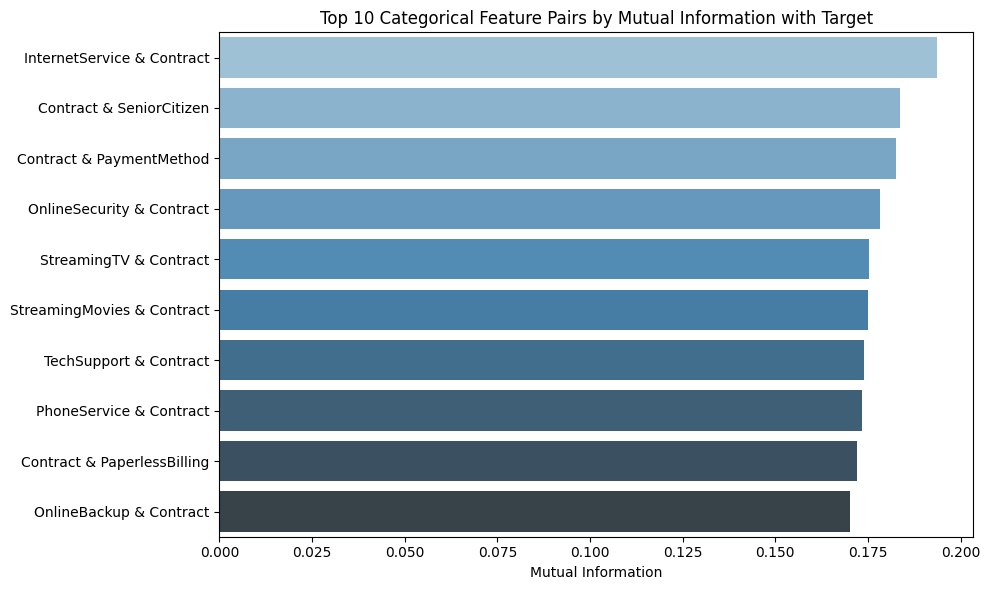

2026-03-28 15:40:00,000 - INFO - Heatmap 1: InternetService & Contract (MI=0.1937)


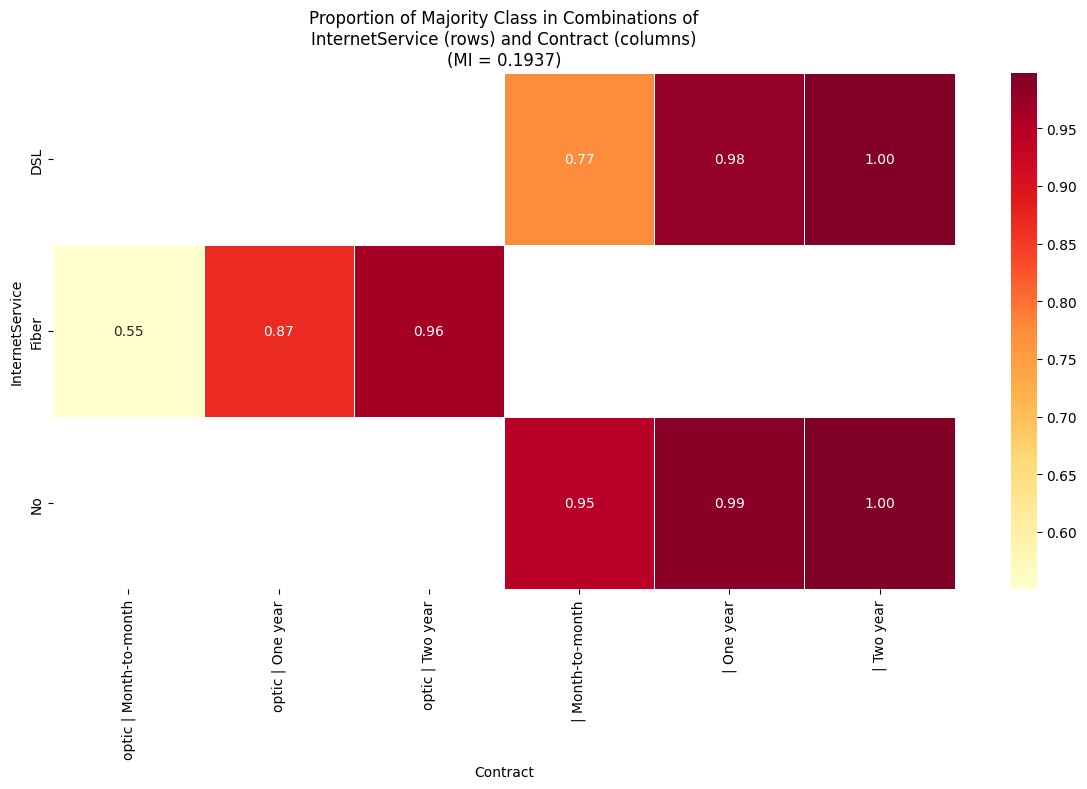


[Interpretation] No specific guidance for categorical_interactions.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import warnings
warnings.filterwarnings('ignore')


class ComprehensiveEDA:
    """
    A comprehensive EDA class with modular analysis components.
    You can run individual analyses, a subset, or all of them.
    
    Available analyses (method names):
        missing_analysis
        target_analysis
        univariate_analysis
        bivariate_analysis
        target_vs_features
        correlation_with_target
        grouped_analysis
        outlier_analysis
        duplicate_analysis
        vif_analysis
        mutual_information_analysis
        statistical_validation
        leakage_detection
        feature_interactions
        missing_as_signal
        drift_detection
        encoding_decisions
        categorical_interactions
        feature_combination_predictiveness
    """
    
    AVAILABLE_ANALYSES = [
        'missing_analysis',
        'target_analysis',
        'univariate_analysis',
        'bivariate_analysis',
        'target_vs_features',
        'correlation_with_target',
        'grouped_analysis',
        'outlier_analysis',
        'duplicate_analysis',
        'vif_analysis',
        'mutual_information_analysis',
        'statistical_validation',
        'leakage_detection',
        'feature_interactions',
        'missing_as_signal',
        'drift_detection',
        'encoding_decisions',
        'categorical_interactions',
        'feature_combination_predictiveness'
    ]

    def __init__(self, file_path, target, task_no, 
                categorical_variance_threshold=0.01,
                categorical_cardinality_threshold=None,
                show_guidance=False):
        """
        Parameters:
        -----------
        file_path : str
            Path to the dataset (CSV, Excel, or Parquet).
        target : str
            Name of the target column.
        task_no : str
            One of 'regression': 1, 'binary classification': 2, or 'multi classification': 3.
        categorical_variance_threshold : float, default=0.01
            Numeric columns with variance below this threshold are treated as categorical.
        categorical_cardinality_threshold : int or None, default=None
            Numeric columns with unique values <= this threshold are treated as categorical.
            If None, the threshold is automatically computed as:
                clamp( int(0.05 * n_rows), min=10, max=50 )
            where n_rows is the number of rows in the dataset.
        show_guidance : bool, default=False
            If True, prints interpretation guidance after each analysis.
        """
        self.file_path = file_path
        self.target = target
        task_map = {
            1: 'regression',
            2: 'binary',
            3: 'multi'
        }
        self.task = task_map[int(task_no)]
        self.cat_var_threshold = categorical_variance_threshold
        self.show_guidance = show_guidance
        self.report = []

        # Load data and identify feature types
        self.df = self._load_data()
        self._validate_target()
        self._detect_datetime_columns()

        # Determine cardinality threshold (auto if None)
        n_rows = len(self.df)
        if categorical_cardinality_threshold is None:
            auto_thresh = int(0.05 * n_rows)
            self.cat_card_threshold = max(10, min(50, auto_thresh))
            logging.info(f"Auto-set categorical cardinality threshold to {self.cat_card_threshold} (5% of {n_rows} rows, clamped to [10,50])")
        else:
            self.cat_card_threshold = categorical_cardinality_threshold
            logging.info(f"Using user-provided categorical cardinality threshold: {self.cat_card_threshold}")

        self.num_cols, self.cat_cols, self.dt_cols = self._get_feature_types()

        # Setup logging (only if no handlers exist)
        if not logging.getLogger().handlers:
            logging.basicConfig(level=logging.INFO,
                                format='%(asctime)s - %(levelname)s - %(message)s',
                                handlers=[logging.StreamHandler(),
                                        logging.FileHandler('eda.log')])
        logging.info(f"EDA initialized: target={target}, task={self.task}, shape={self.df.shape}")

    # -------------------------------------------------------------------------
    # 1. Data loading
    # -------------------------------------------------------------------------
    def _load_data(self):
        """Load dataset from CSV/Excel/Parquet file."""
        try:
            if self.file_path.endswith('.csv'):
                return pd.read_csv(self.file_path)
            elif self.file_path.endswith(('.xlsx', '.xls')):
                return pd.read_excel(self.file_path)
            elif self.file_path.endswith('.parquet'):
                return pd.read_parquet(self.file_path)            
            else:
                raise ValueError("Unsupported file format. Use CSV/Excel/Parquet.")
        except Exception as e:
            logging.error(f"Failed to load dataset: {e}")
            raise

    # -------------------------------------------------------------------------
    # 2. Target validation
    # -------------------------------------------------------------------------
    def _validate_target(self):
        """Check that target exists and task is valid."""
        if self.target not in self.df.columns:
            raise ValueError(f"Target column '{self.target}' not found in dataset.")
        if self.task not in ['regression', 'binary', 'multi']:
            raise ValueError("Task must be 'regression', 'binary', or 'multi'.")

    # -------------------------------------------------------------------------
    # 2b. Detect datetime columns stored as objects
    # -------------------------------------------------------------------------
    def _detect_datetime_columns(self):
        """Convert object columns that look like dates to datetime."""
        for col in self.df.select_dtypes(include='object').columns:
            try:
                sample = self.df[col].dropna().iloc[0]
                pd.to_datetime(sample)
                self.df[col] = pd.to_datetime(self.df[col])
                logging.info(f"Column '{col}' converted to datetime.")
            except (ValueError, TypeError, IndexError):
                continue

    # -------------------------------------------------------------------------
    # 3. Feature type detection
    # -------------------------------------------------------------------------
    def _get_feature_types(self):
        """Identify numeric, categorical, and datetime columns.
        Move low-variance or low-cardinality numeric columns to categorical."""
        num = self.df.select_dtypes(include=np.number).columns.tolist()
        cat = self.df.select_dtypes(include='object').columns.tolist()
        dt = self.df.select_dtypes(include=['datetime', 'datetime64']).columns.tolist()

        if self.target in num:
            num.remove(self.target)
        if self.target in cat:
            cat.remove(self.target)
        if self.target in dt:
            dt.remove(self.target)

        for col in num[:]:
            if self.df[col].isnull().mean() > 0.5:
                continue
            n_unique = self.df[col].nunique()
            if n_unique <= self.cat_card_threshold:
                cat.append(col)
                num.remove(col)
                msg = f"Column '{col}' moved to categorical (unique values={n_unique} <= threshold {self.cat_card_threshold})"
                logging.info(msg)
                self.report.append(msg)
                continue
            var = self.df[col].var()
            if var < self.cat_var_threshold:
                cat.append(col)
                num.remove(col)
                msg = f"Column '{col}' moved to categorical (variance={var:.6f} < threshold {self.cat_var_threshold})"
                logging.info(msg)
                self.report.append(msg)

        return num, cat, dt

    # -------------------------------------------------------------------------
    # 4. Missing data analysis
    # -------------------------------------------------------------------------
    def missing_analysis(self):
        """Visualise missing values (heatmap + bar plot)."""
        missing = self.df.isnull().sum()
        missing = missing[missing > 0]

        if missing.empty:
            logging.info("No missing values found.")
            self.report.append("No missing values found.")
            if self.show_guidance:
                print("\n[Interpretation] No missing values – good data quality.")
            return

        logging.info(f"Missing values:\n{missing}")
        self.report.append(f"Missing values per column:\n{missing}")

        n_rows = len(self.df)
        if n_rows > 10000:
            sample_df = self.df.sample(n=10000, random_state=42)
            logging.info("Sampling 10,000 rows for heatmap due to large dataset.")
        else:
            sample_df = self.df
        plt.figure(figsize=(12, 6))
        sns.heatmap(sample_df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
        plt.title("Missing Data Heatmap")
        plt.tight_layout()
        plt.show()

        missing_pct = (missing / len(self.df)) * 100
        plt.figure(figsize=(12, 6))
        missing_pct.sort_values().plot(kind='bar')
        plt.ylabel('Percentage Missing')
        plt.title('Missing Data Percentage by Column')
        plt.tight_layout()
        plt.show()

        if self.show_guidance:
            self._print_guidance('missing_analysis')

    # -------------------------------------------------------------------------
    # 5. Target variable analysis
    # -------------------------------------------------------------------------
    def target_analysis(self):
        """Analyse target distribution (histogram + boxplot for regression;
           bar + pie for classification)."""
        logging.info("===== TARGET ANALYSIS =====")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        ax1, ax2 = axes

        if self.task == 'regression':
            sns.histplot(self.df[self.target], kde=True, ax=ax1)
            ax1.set_title(f"Distribution of {self.target}")
            sns.boxplot(x=self.df[self.target], ax=ax2)
            ax2.set_title(f"Boxplot of {self.target}")
            stats = self.df[self.target].describe()
            logging.info(f"Target statistics:\n{stats}")
            self.report.append(f"Target statistics:\n{stats}")
        else:
            vc = self.df[self.target].value_counts()
            sns.barplot(x=vc.index, y=vc.values, ax=ax1)
            ax1.set_title(f"Class Distribution of {self.target}")
            ax1.set_xlabel('Class')
            ax1.set_ylabel('Count')
            for i, val in enumerate(vc.values):
                ax1.text(i, val + 0.5, str(val), ha='center')
            ax2.pie(vc.values, labels=vc.index, autopct='%1.1f%%', startangle=90)
            ax2.set_title('Class Proportions')
            imbalance = vc.max() / vc.min()
            logging.info(f"Class counts:\n{vc}")
            logging.info(f"Imbalance Ratio (max/min): {imbalance:.2f}")
            self.report.append(f"Class counts:\n{vc}")
            self.report.append(f"Imbalance Ratio: {imbalance:.2f}")

        plt.tight_layout()
        plt.show()
        if self.show_guidance:
            self._print_guidance('target_analysis')

    # -------------------------------------------------------------------------
    # 6. Univariate analysis
    # -------------------------------------------------------------------------
    def univariate_analysis(self):
        """Plot histograms + boxplots for numeric, bar charts for categorical."""
        logging.info("===== UNIVARIATE ANALYSIS =====")

        if self.num_cols:
            n_cols = min(3, len(self.num_cols))
            n_rows = (len(self.num_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
            for i, col in enumerate(self.num_cols):
                sns.histplot(self.df[col], kde=True, ax=axes[i], color='skyblue')
                axes[i].set_title(f"{col} (skew={self.df[col].skew():.2f})")
                self.report.append(f"{col} skewness: {self.df[col].skew():.2f}")
            for i in range(len(self.num_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()

            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
            for i, col in enumerate(self.num_cols):
                sns.boxplot(x=self.df[col], ax=axes[i], color='lightgreen')
                axes[i].set_title(col)
            for i in range(len(self.num_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()

        if self.cat_cols:
            n_cols = min(3, len(self.cat_cols))
            n_rows = (len(self.cat_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
            for i, col in enumerate(self.cat_cols):
                vc = self.df[col].value_counts()
                sns.barplot(x=vc.index, y=vc.values, ax=axes[i], palette='viridis')
                axes[i].set_title(f"{col} (n_unique={len(vc)})")
                axes[i].tick_params(axis='x', rotation=45)
                for j, val in enumerate(vc.values):
                    axes[i].text(j, val + 0.5, str(val), ha='center', fontsize=8)
            for i in range(len(self.cat_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()

        if self.show_guidance:
            self._print_guidance('univariate_analysis')

    # -------------------------------------------------------------------------
    # 7. Bivariate analysis
    # -------------------------------------------------------------------------
    def bivariate_analysis(self):
        """Pairplot for numeric; boxplots for categorical vs numeric."""
        logging.info("===== BIVARIATE ANALYSIS =====")

        if len(self.num_cols) >= 2:
            if len(self.num_cols) > 10:
                logging.warning("Too many numerical columns (>10). Skipping pairplot to avoid memory issues.")
            else:
                sns.pairplot(self.df[self.num_cols], diag_kind='kde')
                plt.suptitle('Pairplot of Numerical Features', y=1.02)
                plt.show()

        if self.cat_cols and self.num_cols:
            n_rows = len(self.cat_cols)
            n_cols = len(self.num_cols)
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
            if n_rows == 1 and n_cols == 1:
                axes = [[axes]]
            elif n_rows == 1:
                axes = [axes]
            elif n_cols == 1:
                axes = [[ax] for ax in axes]

            for i, cat in enumerate(self.cat_cols):
                for j, num in enumerate(self.num_cols):
                    ax = axes[i][j]
                    sns.boxplot(x=self.df[cat], y=self.df[num], ax=ax)
                    ax.set_title(f"{cat} vs {num}")
                    ax.tick_params(axis='x', rotation=45)
                    if i == n_rows - 1:
                        ax.set_xlabel(cat)
                    if j == 0:
                        ax.set_ylabel(num)
            plt.tight_layout()
            plt.show()

        if self.show_guidance:
            self._print_guidance('bivariate_analysis')

    # -------------------------------------------------------------------------
    # 8. Target vs features
    # -------------------------------------------------------------------------
    def target_vs_features(self):
        """Numerical vs target (scatter/box); categorical vs target (stacked bar) in subplots."""
        logging.info("===== TARGET vs FEATURES =====")

        if self.num_cols:
            n_cols = min(3, len(self.num_cols))
            n_rows = (len(self.num_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

            for i, col in enumerate(self.num_cols):
                if self.task == 'regression':
                    sns.scatterplot(x=self.df[col], y=self.df[self.target], ax=axes[i], alpha=0.5)
                    axes[i].set_title(f"{col} vs {self.target}")
                else:
                    if self.df[self.target].nunique() > 20:
                        logging.warning(f"Target has {self.df[self.target].nunique()} unique values. Boxplot may be crowded.")
                    sns.boxplot(x=self.df[self.target], y=self.df[col], ax=axes[i])
                    axes[i].set_title(f"{col} vs {self.target}")
                    axes[i].tick_params(axis='x', rotation=45)
            for i in range(len(self.num_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()

        if self.cat_cols and self.task != 'regression':
            n_cols = min(3, len(self.cat_cols))
            n_rows = (len(self.cat_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

            for i, col in enumerate(self.cat_cols):
                crosstab = pd.crosstab(self.df[col], self.df[self.target], normalize='index') * 100
                crosstab.plot(kind='bar', stacked=True, ax=axes[i], legend=False)
                axes[i].set_title(f"{col} vs {self.target} (normalized %)")
                axes[i].set_xlabel(col)
                axes[i].set_ylabel('Percentage')
                axes[i].tick_params(axis='x', rotation=45)
                if i == 0:
                    axes[i].legend(title=self.target, loc='upper right')
            for i in range(len(self.cat_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()

        if self.show_guidance:
            self._print_guidance('target_vs_features')

    # -------------------------------------------------------------------------
    # 9. Correlation with target (regression only)
    # -------------------------------------------------------------------------
    def correlation_with_target(self):
        if self.task == 'regression' and self.num_cols:
            logging.info("===== FEATURE IMPORTANCE (Correlation) =====")
            corr = self.df[self.num_cols + [self.target]].corr()[self.target].drop(self.target).sort_values(ascending=False)
            logging.info(f"Correlation with target:\n{corr}")
            self.report.append(f"Correlation with target:\n{corr}")
            plt.figure(figsize=(10, 6))
            sns.barplot(x=corr.values, y=corr.index, palette='coolwarm')
            plt.title(f'Correlation with Target: {self.target}')
            plt.xlabel('Correlation Coefficient')
            plt.tight_layout()
            plt.show()
            if self.show_guidance:
                self._print_guidance('correlation_with_target')
        else:
            if self.show_guidance:
                print("[Interpretation] Correlation with target is only applicable for regression tasks. Skipped.")

    # -------------------------------------------------------------------------
    # 10. Grouped analysis (categorical vs target mean, regression only)
    # -------------------------------------------------------------------------
    def grouped_analysis(self):
        if self.task == 'regression' and self.cat_cols:
            logging.info("===== GROUPED ANALYSIS (Categorical vs Target Mean) =====")
            n_cols = min(3, len(self.cat_cols))
            n_rows = (len(self.cat_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
            axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

            for i, col in enumerate(self.cat_cols):
                grouped = self.df.groupby(col)[self.target].mean().sort_values()
                sns.barplot(x=grouped.index, y=grouped.values, ax=axes[i])
                axes[i].set_title(f"{col} -> Mean {self.target}")
                axes[i].tick_params(axis='x', rotation=45)
                for j, val in enumerate(grouped.values):
                    axes[i].text(j, val + 0.01, f"{val:.2f}", ha='center', fontsize=8)
            for i in range(len(self.cat_cols), len(axes)):
                axes[i].set_visible(False)
            plt.tight_layout()
            plt.show()
            if self.show_guidance:
                self._print_guidance('grouped_analysis')
        else:
            if self.show_guidance and self.task == 'regression':
                print("[Interpretation] No categorical features available for grouped analysis.")

    # -------------------------------------------------------------------------
    # 11. Outlier detection (Z-score + boxplots)
    # -------------------------------------------------------------------------
    def outlier_analysis(self):
        if not self.num_cols:
            if self.show_guidance:
                print("[Interpretation] No numerical columns to analyze for outliers.")
            return
        logging.info("===== OUTLIERS DETECTION =====")
        n_cols = min(3, len(self.num_cols))
        n_rows = (len(self.num_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
        axes = axes.flatten() if n_rows * n_cols > 1 else [axes]

        for i, col in enumerate(self.num_cols):
            if self.df[col].std() == 0:
                outliers = 0
                logging.info(f"{col}: constant column, no outliers.")
            else:
                z = np.abs((self.df[col] - self.df[col].mean()) / self.df[col].std())
                outliers = (z > 3).sum()
            logging.info(f"{col}: {outliers} outliers (Z>3)")
            self.report.append(f"{col}: {outliers} outliers (Z>3)")
            sns.boxplot(x=self.df[col], ax=axes[i])
            axes[i].set_title(f"{col} (outliers={outliers})")
        for i in range(len(self.num_cols), len(axes)):
            axes[i].set_visible(False)
        plt.tight_layout()
        plt.show()
        if self.show_guidance:
            self._print_guidance('outlier_analysis')

    # -------------------------------------------------------------------------
    # 12. Duplicate analysis
    # -------------------------------------------------------------------------
    def duplicate_analysis(self):
        duplicates = self.df.duplicated().sum()
        if duplicates > 0:
            logging.info(f"Found {duplicates} duplicate rows.")
            self.report.append(f"Duplicate rows: {duplicates}")
            dup_examples = self.df[self.df.duplicated(keep=False)].head(5)
            logging.info(f"First few duplicate rows:\n{dup_examples}")
            self.report.append(f"First few duplicate rows:\n{dup_examples}")
        else:
            logging.info("No duplicate rows found.")
            self.report.append("No duplicate rows found.")
        if self.show_guidance:
            self._print_guidance('duplicate_analysis')

    # -------------------------------------------------------------------------
    # 13. VIF analysis (regression only)
    # -------------------------------------------------------------------------
    def vif_analysis(self):
        if self.task != 'regression' or len(self.num_cols) < 2:
            logging.info("VIF analysis skipped (not regression or insufficient numeric features).")
            if self.show_guidance:
                print("[Interpretation] VIF analysis requires regression task with at least two numeric features.")
            return
        try:
            from statsmodels.stats.outliers_influence import variance_inflation_factor
        except ImportError:
            logging.error("statsmodels not installed. Cannot compute VIF.")
            if self.show_guidance:
                print("[Interpretation] VIF analysis requires statsmodels. Please install with: pip install statsmodels")
            return
        X = self.df[self.num_cols].dropna()
        vif_data = pd.DataFrame()
        vif_data["feature"] = X.columns
        vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        vif_data = vif_data.sort_values("VIF", ascending=False)
        logging.info(f"VIF scores:\n{vif_data}")
        self.report.append(f"VIF scores:\n{vif_data}")
        plt.figure(figsize=(10, 6))
        sns.barplot(data=vif_data, x="VIF", y="feature", palette="rocket")
        plt.axvline(x=5, color='red', linestyle='--', label='Threshold (5)')
        plt.axvline(x=10, color='orange', linestyle='--', label='High (10)')
        plt.title("Variance Inflation Factor (VIF)")
        plt.legend()
        plt.tight_layout()
        plt.show()
        if self.show_guidance:
            self._print_guidance('vif_analysis')

    # -------------------------------------------------------------------------
    # 14. Mutual Information
    # -------------------------------------------------------------------------
    def mutual_information_analysis(self):
        try:
            from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
        except ImportError:
            logging.error("scikit-learn not installed. Cannot compute mutual information.")
            if self.show_guidance:
                print("[Interpretation] Mutual information analysis requires scikit-learn. Please install with: pip install scikit-learn")
            return
        X = self.df[self.num_cols + self.cat_cols].copy()
        y = self.df[self.target]
        from sklearn.preprocessing import LabelEncoder
        for col in self.cat_cols:
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))
        X_clean = X.dropna()
        y_clean = y.loc[X_clean.index]
        if self.task == 'regression':
            mi = mutual_info_regression(X_clean, y_clean, random_state=42)
        else:
            mi = mutual_info_classif(X_clean, y_clean, random_state=42)
        mi_df = pd.DataFrame({'feature': X.columns, 'mutual_info': mi})
        mi_df = mi_df.sort_values('mutual_info', ascending=False)
        logging.info(f"Mutual Information scores:\n{mi_df}")
        self.report.append(f"Mutual Information scores:\n{mi_df}")
        plt.figure(figsize=(10, 6))
        sns.barplot(data=mi_df, x='mutual_info', y='feature', palette='viridis')
        plt.title(f"Mutual Information with Target ({self.task})")
        plt.tight_layout()
        plt.show()
        if self.show_guidance:
            self._print_guidance('mutual_information_analysis')

    # -------------------------------------------------------------------------
    # 15. Statistical validation
    # -------------------------------------------------------------------------
    def statistical_validation(self):
        logging.info("===== STATISTICAL VALIDATION =====")
        try:
            from scipy import stats
        except ImportError:
            logging.error("scipy not installed. Cannot run statistical validation.")
            if self.show_guidance:
                print("[Interpretation] Statistical validation requires scipy. Please install with: pip install scipy")
            return
        if self.num_cols:
            logging.info("Normality tests (Shapiro-Wilk):")
            for col in self.num_cols[:5]:
                sample = self.df[col].dropna()
                if len(sample) > 5000:
                    sample = sample.sample(5000, random_state=42)
                if len(sample) >= 3:
                    stat, p = stats.shapiro(sample)
                    normal = p > 0.05
                    logging.info(f"{col}: p={p:.4f} -> {'Normal' if normal else 'Not normal'}")
                    self.report.append(f"{col} normality p={p:.4f} -> {'Normal' if normal else 'Not normal'}")
                else:
                    logging.info(f"{col}: insufficient data for normality test (n={len(sample)})")
            if self.show_guidance:
                print("\n[Interpretation] Normality: p>0.05 suggests normality; many non-normal features may need transformation.")
        if self.task == 'regression':
            if self.cat_cols and self.num_cols:
                logging.info("ANOVA / t-test between categorical features and numeric target:")
                for cat in self.cat_cols:
                    groups = []
                    categories = self.df[cat].dropna().unique()
                    for val in categories:
                        group_data = self.df[self.target][self.df[cat] == val].dropna()
                        if len(group_data) >= 2:
                            groups.append(group_data)
                    if len(groups) >= 2:
                        if len(groups) == 2:
                            _, p = stats.ttest_ind(*groups, equal_var=False)
                            test = "t-test"
                        else:
                            _, p = stats.f_oneway(*groups)
                            test = "ANOVA"
                        logging.info(f"{cat} vs {self.target}: {test} p={p:.4f}")
                        self.report.append(f"{cat} vs {self.target}: {test} p={p:.4f}")
                    else:
                        logging.info(f"{cat}: insufficient non-empty groups (>=2 groups with >=2 samples each)")
        else:
            if self.num_cols:
                logging.info("ANOVA: numerical features vs categorical target:")
                for num in self.num_cols:
                    groups = []
                    target_classes = self.df[self.target].dropna().unique()
                    for cls in target_classes:
                        group_data = self.df[num][self.df[self.target] == cls].dropna()
                        if len(group_data) >= 2:
                            groups.append(group_data)
                    if len(groups) >= 2:
                        if len(groups) == 2:
                            _, p = stats.ttest_ind(*groups, equal_var=False)
                            test = "t-test"
                        else:
                            _, p = stats.f_oneway(*groups)
                            test = "ANOVA"
                        logging.info(f"{num} vs target: {test} p={p:.4f}")
                        self.report.append(f"{num} vs target: {test} p={p:.4f}")
                    else:
                        logging.info(f"{num}: insufficient data for ANOVA (need >=2 classes with >=2 samples each)")
            if self.cat_cols:
                logging.info("Chi-square: categorical features vs categorical target:")
                for cat in self.cat_cols:
                    ct = pd.crosstab(self.df[cat], self.df[self.target])
                    if ct.shape[0] >= 2 and ct.shape[1] >= 2:
                        chi2, p, dof, expected = stats.chi2_contingency(ct)
                        logging.info(f"{cat} vs target: chi2={chi2:.2f}, p={p:.4f}")
                        self.report.append(f"{cat} vs target: chi-square p={p:.4f}")
                    else:
                        logging.info(f"{cat}: insufficient categories for chi-square test (need at least 2 unique in each)")
        if self.task == 'regression':
            logging.info("Regression assumptions check: linearity, homoscedasticity, normality of residuals should be checked after model fitting.")
            self.report.append("Regression assumptions: linearity, homoscedasticity, normality of residuals – verify with residual plots.")
        if self.show_guidance:
            self._print_guidance('statistical_validation')

    # -------------------------------------------------------------------------
    # 16. Leakage detection
    # -------------------------------------------------------------------------
    def leakage_detection(self, target_correlation_threshold=0.95):
        logging.info("===== LEAKAGE DETECTION =====")
        if self.task == 'regression' and self.num_cols:
            corr = self.df[self.num_cols].corrwith(self.df[self.target]).abs()
            high_corr = corr[corr > target_correlation_threshold]
            if not high_corr.empty:
                logging.info(f"Potential leakage: features with |corr| > {target_correlation_threshold}:\n{high_corr}")
                self.report.append(f"Potential leakage (high correlation): {high_corr.index.tolist()}")
            else:
                logging.info("No features with suspiciously high correlation to target.")
                self.report.append("No high-correlation leakage detected.")
        for col in self.df.columns:
            if self.df[col].nunique() == len(self.df) and self.df[col].dtype in [np.number, 'object']:
                logging.info(f"Column '{col}' appears to be a unique identifier (potential leakage if used as feature).")
                self.report.append(f"Unique identifier column: {col}")
        if self.show_guidance:
            self._print_guidance('leakage_detection')

    # -------------------------------------------------------------------------
    # 17. Feature interactions
    # -------------------------------------------------------------------------
    def feature_interactions(self, top_n=5):
        logging.info("===== FEATURE INTERACTIONS =====")
        try:
            from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
        except ImportError:
            logging.error("scikit-learn not installed. Cannot compute feature interactions.")
            if self.show_guidance:
                print("[Interpretation] Feature interactions require scikit-learn.")
            return
        X = self.df[self.num_cols + self.cat_cols].copy()
        y = self.df[self.target]
        from sklearn.preprocessing import LabelEncoder
        for col in self.cat_cols:
            X[col] = LabelEncoder().fit_transform(X[col].astype(str))
        X_clean = X.dropna()
        y_clean = y.loc[X_clean.index]
        from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
        if self.task == 'regression':
            model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
        else:
            model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        model.fit(X_clean, y_clean)
        logging.info("Feature interactions can be explored using interaction terms (e.g., product of features) or tree-based interaction detection.")
        self.report.append("Feature interactions: explore pairwise products or tree-based methods for deeper insights.")
        if self.show_guidance:
            self._print_guidance('feature_interactions')

    # -------------------------------------------------------------------------
    # 18. Missing as signal
    # -------------------------------------------------------------------------
    def missing_as_signal(self):
        logging.info("===== MISSING AS SIGNAL =====")
        missing_cols = self.df.columns[self.df.isnull().any()].tolist()
        if not missing_cols:
            logging.info("No missing columns to analyse.")
            if self.show_guidance:
                print("[Interpretation] No missing data to treat as signal.")
            return
        missing_indicators = {}
        for col in missing_cols:
            indicator_name = f"{col}_missing"
            self.df[indicator_name] = self.df[col].isnull().astype(int)
            missing_indicators[col] = indicator_name
        logging.info("Testing missing indicators vs target:")
        for orig, ind in missing_indicators.items():
            if self.task == 'regression':
                corr = self.df[ind].corr(self.df[self.target])
                logging.info(f"Missing indicator for '{orig}' correlation with target: {corr:.4f}")
                self.report.append(f"Missing indicator '{orig}' correlation with target: {corr:.4f}")
            else:
                from scipy.stats import chi2_contingency
                cross = pd.crosstab(self.df[ind], self.df[self.target])
                chi2, p, dof, expected = chi2_contingency(cross)
                logging.info(f"Missing indicator for '{orig}' vs target: chi2={chi2:.2f}, p={p:.4f}")
                self.report.append(f"Missing indicator '{orig}' vs target: p={p:.4f}")
        if self.show_guidance:
            self._print_guidance('missing_as_signal')

    # -------------------------------------------------------------------------
    # 19. Drift detection
    # -------------------------------------------------------------------------
    def drift_detection(self, test_df=None, time_col=None):
        logging.info("===== DRIFT DETECTION =====")
        if test_df is not None:
            for col in self.num_cols + self.cat_cols:
                train = self.df[col].dropna()
                test = test_df[col].dropna()
                if col in self.num_cols:
                    from scipy.stats import ks_2samp
                    stat, p = ks_2samp(train, test)
                    logging.info(f"{col}: KS test p={p:.4f}")
                    self.report.append(f"{col}: drift p-value={p:.4f}")
                else:
                    from scipy.stats import chi2_contingency
                    train_counts = train.value_counts()
                    test_counts = test.value_counts()
                    all_cats = set(train_counts.index) | set(test_counts.index)
                    train_arr = [train_counts.get(cat, 0) for cat in all_cats]
                    test_arr = [test_counts.get(cat, 0) for cat in all_cats]
                    if sum(train_arr) > 0 and sum(test_arr) > 0:
                        _, p, _, _ = chi2_contingency([train_arr, test_arr])
                        logging.info(f"{col}: chi-square p={p:.4f}")
                        self.report.append(f"{col}: drift p-value={p:.4f}")
                    else:
                        logging.info(f"{col}: cannot compute chi2 due to empty categories.")
        elif time_col is not None and time_col in self.dt_cols:
            self.df[time_col] = pd.to_datetime(self.df[time_col])
            mid = self.df[time_col].median()
            train_mask = self.df[time_col] <= mid
            test_mask = self.df[time_col] > mid
            for col in self.num_cols + self.cat_cols:
                train = self.df.loc[train_mask, col].dropna()
                test = self.df.loc[test_mask, col].dropna()
                if col in self.num_cols:
                    from scipy.stats import ks_2samp
                    stat, p = ks_2samp(train, test)
                    logging.info(f"{col}: KS test p={p:.4f}")
                    self.report.append(f"{col}: drift p-value={p:.4f}")
                else:
                    from scipy.stats import chi2_contingency
                    train_counts = train.value_counts()
                    test_counts = test.value_counts()
                    all_cats = set(train_counts.index) | set(test_counts.index)
                    train_arr = [train_counts.get(cat, 0) for cat in all_cats]
                    test_arr = [test_counts.get(cat, 0) for cat in all_cats]
                    _, p, _, _ = chi2_contingency([train_arr, test_arr])
                    logging.info(f"{col}: chi-square p={p:.4f}")
                    self.report.append(f"{col}: drift p-value={p:.4f}")
        else:
            logging.info("Drift detection requires either a test dataset or a datetime column.")
            if self.show_guidance:
                print("[Interpretation] Provide a test_df or specify time_col to detect drift.")
        if self.show_guidance:
            self._print_guidance('drift_detection')

    # -------------------------------------------------------------------------
    # 20. Encoding decisions
    # -------------------------------------------------------------------------
    def encoding_decisions(self, cardinality_threshold=20):
        logging.info("===== ENCODING DECISIONS =====")
        suggestions = {}
        for col in self.cat_cols:
            n_unique = self.df[col].nunique()
            if n_unique <= 2:
                suggestions[col] = "Label encoding (binary)"
            elif n_unique <= cardinality_threshold:
                suggestions[col] = "One-hot encoding"
            else:
                if self.task == 'regression':
                    suggestions[col] = "Target encoding (mean target per category) or frequency encoding"
                else:
                    suggestions[col] = "Target encoding (probability of class) or frequency encoding"
            logging.info(f"{col}: {n_unique} categories -> {suggestions[col]}")
            self.report.append(f"{col}: encoding suggestion = {suggestions[col]}")
        if self.show_guidance:
            self._print_guidance('encoding_decisions')

    # -------------------------------------------------------------------------
    # 21. Categorical interactions
    # -------------------------------------------------------------------------
    def categorical_interactions(self, top_n=10, heatmaps_for_top_n=1, max_categories_per_feature=20):
        """
        Discover and visualize interactions between categorical features in classification tasks.
        
        Parameters:
        top_n : int, default=10
            Number of top feature pairs to display in bar chart.
        heatmaps_for_top_n : int, default=1
            Number of top pairs for which to generate heatmaps.
            If set > number of available pairs, it is clamped to that number.
        max_categories_per_feature : int, default=20
            If a categorical feature has more unique values than this, it is skipped.
        """
        if self.task == 'regression':
            logging.info("Categorical interactions analysis is intended for classification tasks. Skipping.")
            if self.show_guidance:
                print("[Interpretation] Categorical interactions are most useful for classification. Skipped.")
            return

        if len(self.cat_cols) < 2:
            logging.info("Need at least two categorical columns for interaction analysis.")
            if self.show_guidance:
                print("[Interpretation] Need at least two categorical features for interaction analysis.")
            return

        logging.info("===== CATEGORICAL FEATURE INTERACTIONS =====")
        usable_cats = [col for col in self.cat_cols if self.df[col].nunique() <= max_categories_per_feature]
        if len(usable_cats) < 2:
            logging.info(f"After filtering by cardinality (≤{max_categories_per_feature}), insufficient features.")
            return

        from sklearn.feature_selection import mutual_info_classif
        from sklearn.preprocessing import LabelEncoder
        import warnings
        warnings.filterwarnings('ignore')
        y = self.df[self.target]
        scores = []
        for i in range(len(usable_cats)):
            for j in range(i+1, len(usable_cats)):
                col1, col2 = usable_cats[i], usable_cats[j]
                combined = self.df[col1].astype(str) + '_' + self.df[col2].astype(str)
                le = LabelEncoder()
                combined_encoded = le.fit_transform(combined)
                mi = mutual_info_classif(combined_encoded.reshape(-1,1), y, random_state=42)[0]
                scores.append((col1, col2, mi))

        if not scores:
            logging.info("No interaction scores computed.")
            return

        scores.sort(key=lambda x: x[2], reverse=True)
        top_pairs = scores[:top_n]
        n_pairs = len(top_pairs)

        # Clamp heatmaps_for_top_n to available pairs
        if heatmaps_for_top_n > n_pairs:
            logging.warning(f"Requested {heatmaps_for_top_n} heatmaps but only {n_pairs} pairs available. Showing all.")
            heatmaps_for_top_n = n_pairs
        if heatmaps_for_top_n < 0:
            heatmaps_for_top_n = 0

        # Bar chart of top pairs
        plt.figure(figsize=(10, 6))
        pair_labels = [f"{p[0]} & {p[1]}" for p in top_pairs]
        mi_vals = [p[2] for p in top_pairs]
        sns.barplot(x=mi_vals, y=pair_labels, palette='Blues_d')
        plt.title(f"Top {top_n} Categorical Feature Pairs by Mutual Information with Target")
        plt.xlabel('Mutual Information')
        plt.tight_layout()
        plt.show()

        # Generate heatmaps for the requested number of top pairs
        for idx, (col1, col2, mi) in enumerate(top_pairs[:heatmaps_for_top_n]):
            logging.info(f"Heatmap {idx+1}: {col1} & {col2} (MI={mi:.4f})")
            self.report.append(f"Categorical interaction heatmap {idx+1}: {col1} & {col2} (MI={mi:.4f})")
            
            combo = self.df[col1].astype(str) + ' | ' + self.df[col2].astype(str)
            target_dist = pd.crosstab(combo, self.df[self.target], normalize='index')
            max_prop = target_dist.max(axis=1)

            # Split only on the first separator to avoid extra columns
            index_df = target_dist.index.to_series().str.split(' | ', n=1, expand=True)
            index_df.columns = [col1, col2]

            heatmap_df = pd.DataFrame({
                col1: index_df[col1],
                col2: index_df[col2],
                'max_prop': max_prop.values
            })
            pivot = heatmap_df.pivot(index=col1, columns=col2, values='max_prop')

            plt.figure(figsize=(12, 8))
            sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
            plt.title(f"Proportion of Majority Class in Combinations of\n{col1} (rows) and {col2} (columns)\n(MI = {mi:.4f})")
            plt.tight_layout()
            plt.show()

        if self.show_guidance:
            self._print_guidance('categorical_interactions')
        
    # -------------------------------------------------------------------------
    # 22. Feature combination predictiveness
    # -------------------------------------------------------------------------
    def feature_combination_predictiveness(self, max_combinations=50, test_size=0.2):
        if self.task == 'regression':
            logging.info("Feature combination analysis is primarily for classification tasks. Skipping.")
            if self.show_guidance:
                print("[Interpretation] Feature combination analysis is most useful for classification. Skipped.")
            return
        if len(self.cat_cols) < 2:
            logging.info("Need at least two categorical columns for combination analysis.")
            return
        logging.info("===== FEATURE COMBINATION PREDICTIVENESS =====")
        from sklearn.model_selection import train_test_split
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import accuracy_score
        from sklearn.feature_extraction import FeatureHasher
        from sklearn.preprocessing import LabelEncoder
        X_base = self.df[self.num_cols + self.cat_cols].copy()
        for col in self.cat_cols:
            X_base[col] = LabelEncoder().fit_transform(X_base[col].astype(str))
        X_base = X_base.fillna(X_base.median())
        y = self.df[self.target]
        X_train, X_test, y_train, y_test = train_test_split(X_base, y, test_size=test_size, random_state=42, stratify=y)
        base_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        base_model.fit(X_train, y_train)
        base_acc = accuracy_score(y_test, base_model.predict(X_test))
        hasher = FeatureHasher(n_features=100, input_type='string')
        all_cats_combo = self.df[self.cat_cols].astype(str).agg('_'.join, axis=1)
        hashed_all = hasher.transform(all_cats_combo.values.reshape(-1,1)).toarray()
        X_all = np.hstack([X_base, hashed_all])
        X_train2, X_test2, y_train2, y_test2 = train_test_split(X_all, y, test_size=test_size, random_state=42, stratify=y)
        combo_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        combo_model.fit(X_train2, y_train2)
        combo_acc = accuracy_score(y_test2, combo_model.predict(X_test2))
        improvement = combo_acc - base_acc
        logging.info(f"Base model accuracy: {base_acc:.4f}")
        logging.info(f"Model with all categorical combinations: {combo_acc:.4f}")
        logging.info(f"Improvement: {improvement:.4f}")
        self.report.append(f"Base model accuracy: {base_acc:.4f}")
        self.report.append(f"Accuracy with categorical combinations: {combo_acc:.4f}")
        self.report.append(f"Improvement: {improvement:.4f}")
        if improvement > 0:
            print(f"\n✅ Adding categorical combinations improved accuracy by {improvement:.4f}.")
        else:
            print(f"\n⚠️ Adding categorical combinations did not improve accuracy (change = {improvement:.4f}).")
        if self.show_guidance:
            self._print_guidance('feature_combination_predictiveness')

    # -------------------------------------------------------------------------
    # 23. Save final report
    # -------------------------------------------------------------------------
    def save_report(self):
        """Write the accumulated report to a text file with UTF-8 encoding."""
        with open("eda_master_report.txt", "w", encoding='utf-8') as f:
            f.write("EDA MASTER REPORT\n")
            f.write("=" * 50 + "\n\n")
            f.write(f"Dataset: {self.file_path}\n")
            f.write(f"Shape: {self.df.shape}\n")
            f.write(f"Target: {self.target}\n")
            f.write(f"Task: {self.task}\n")
            f.write(f"Categorical variance threshold: {self.cat_var_threshold}\n\n")
            f.write("-- Summary --\n")
            for line in self.report:
                f.write(line + "\n")
        logging.info("✅ Full EDA completed. Report saved as 'eda_master_report.txt'")

    # -------------------------------------------------------------------------
    # 24. Interpretation guidance printer
    # -------------------------------------------------------------------------
    def _print_guidance(self, analysis_name):
        """Print interpretation guidance for a given analysis."""
        guidance = {
            'missing_analysis': (
                "\n[Interpretation] Missing values:\n"
                "  - Columns with >20% missing may need imputation or dropping.\n"
                "  - Check if missingness is random or systematic.\n"
                "  - Use heatmap to see patterns (e.g., missing in one column often implies missing in another)."
            ),
            'target_analysis': (
                f"\n[Interpretation] Target variable ({self.task}):\n"
                + ("  - Check distribution shape and outliers.\n"
                   "  - Skewed targets may benefit from log transformation.\n"
                   if self.task == 'regression' else
                   "  - Check class balance; high imbalance may require resampling.\n"
                   "  - For multi-class, ensure all classes have enough samples.")
            ),
            'univariate_analysis': (
                "\n[Interpretation] Univariate:\n"
                "  - Numeric: |skew|>0.5 suggests skewness; consider transformation.\n"
                "  - Boxplots show outliers – decide whether to cap or keep.\n"
                "  - Categorical: rare categories may be grouped or cause overfitting."
            ),
            'bivariate_analysis': (
                "\n[Interpretation] Bivariate:\n"
                "  - Pairplot: strong correlations (|r|>0.7) indicate multicollinearity.\n"
                "  - Boxplots (cat vs num): large differences in medians suggest predictive power."
            ),
            'target_vs_features': (
                f"\n[Interpretation] Target vs Features:\n"
                + ("  - Scatter plots: look for linear/non-linear patterns, outliers.\n"
                   "  - Strong trends suggest important predictors.\n"
                   if self.task == 'regression' else
                   "  - Boxplots: features that separate classes well are valuable.\n"
                   "  - Stacked bar plots: categories strongly associated with a class are good features.")
            ),
            'correlation_with_target': (
                "\n[Interpretation] Correlation with target:\n"
                "  - |corr|>0.5 indicates strong linear relationship.\n"
                "  - Low correlation doesn't rule out non-linear relationship."
            ),
            'grouped_analysis': (
                "\n[Interpretation] Grouped analysis:\n"
                "  - Large differences in mean target across categories suggest high predictive power.\n"
                "  - Categories with high variance may need careful handling."
            ),
            'outlier_analysis': (
                "\n[Interpretation] Outliers:\n"
                "  - Outliers may be data errors or genuine extremes.\n"
                "  - If >5% of values are outliers, the column may be heavy-tailed.\n"
                "  - Consider robust scaling or capping."
            ),
            'duplicate_analysis': (
                "\n[Interpretation] Duplicates:\n"
                "  - Duplicate rows can bias model if not intentional.\n"
                "  - Decide whether to keep or drop based on domain."
            ),
            'vif_analysis': (
                "\n[Interpretation] VIF (multicollinearity):\n"
                "  - VIF > 5: moderate multicollinearity; >10: high.\n"
                "  - Consider dropping or combining highly collinear features."
            ),
            'mutual_information_analysis': (
                "\n[Interpretation] Mutual Information:\n"
                "  - MI measures any dependency (linear or non-linear).\n"
                "  - Higher MI = stronger relationship with target.\n"
                "  - Use for feature selection, especially when linear correlation fails."
            )
        }
        print(guidance.get(analysis_name, f"\n[Interpretation] No specific guidance for {analysis_name}."))

    # -------------------------------------------------------------------------
    # 25. Orchestration methods
    # -------------------------------------------------------------------------
    def list_analyses(self):
        """Print the names of all available analysis methods."""
        print("Available analyses (call as methods):")
        for name in self.AVAILABLE_ANALYSES:
            print(f"  - {name}")

    def run(self, analyses=None):
        """
        Run a selection of analyses.

        Parameters:
        -----------
        analyses : list or str, optional
            - If None (default), runs all analyses.
            - If a string, runs that single analysis.
            - If a list of strings, runs each analysis in the list.
            The strings should be method names from AVAILABLE_ANALYSES.
        """
        if analyses is None:
            analyses = self.AVAILABLE_ANALYSES
        elif isinstance(analyses, str):
            analyses = [analyses]

        for name in analyses:
            if name not in self.AVAILABLE_ANALYSES:
                logging.warning(f"Unknown analysis '{name}'. Skipping. Available: {self.AVAILABLE_ANALYSES}")
                continue
            method = getattr(self, name, None)
            if method is not None:
                logging.info(f"Running analysis: {name}")
                method()
            else:
                logging.warning(f"Method '{name}' not found. Skipping.")

    def run_all(self):
        """Convenience method to run all analyses (same as run())."""
        self.run()


# ============================================================================
# Usage Example
# ============================================================================
if __name__ == "__main__":
    # Configure logging (only if not already configured)
    if not logging.getLogger().handlers:
        logging.basicConfig(level=logging.INFO,
                            format='%(asctime)s - %(levelname)s - %(message)s',
                            handlers=[logging.StreamHandler(),
                                      logging.FileHandler('eda.log')])

    # Get user input
    file_path = input("Enter dataset path: ")
    target = input("Enter target column: ")
    task = input("Task type no | regression: 1 | binary classification: 2 | multi classification: 3: ")

    # Ask for guidance preference
    guidance = input("Show interpretation guidance after each analysis? (y/n): ").strip().lower()
    show_guidance = guidance == 'y'

    # Create EDA object
    eda = ComprehensiveEDA(file_path, target, task, show_guidance=show_guidance)

    print("\nChoose how to run:")
    print("1. Run all analyses")
    print("2. Run specific analyses")
    choice = input("Enter choice (1 or 2): ").strip()

    if choice == '1':
        eda.run_all()
    elif choice == '2':
        eda.list_analyses()
        selected = input("Enter analysis names separated by commas (e.g., missing_analysis,target_analysis): ").strip()
        if selected:
            selected_list = [s.strip() for s in selected.split(',') if s.strip()]
            eda.run(selected_list)
        else:
            print("No analyses selected. Exiting.")
    else:
        print("Invalid choice.")